In [94]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import mcstasscript as ms
from scipy.optimize import curve_fit  

In [95]:
import numpy as np

def closed_hollow_cylinder_volume(outer_radius, outer_height, wall_thickness):
    inner_radius = outer_radius - wall_thickness
    inner_height = outer_height - 2 * wall_thickness

    if inner_radius < 0:
        raise ValueError("wall_thickness must be smaller than outer_radius")
    if inner_height < 0:
        raise ValueError("wall_thickness is too large for the given height")

    outer_volume = np.pi * outer_radius**2 * outer_height
    inner_void_volume = np.pi * inner_radius**2 * inner_height

    return outer_volume - inner_void_volume

# Example values in meters
outer_radius = 0.005
outer_height = 0.050
wall_thickness = 0.001

volume_m3 = closed_hollow_cylinder_volume(outer_radius, outer_height, wall_thickness)
volume_cm3 = volume_m3 * 1e6

print(f"Inner radius: {outer_radius - wall_thickness:.6f} m")
print(f"Inner height: {outer_height - 2 * wall_thickness:.6f} m")
print(f"Volume: {volume_m3:.8e} m^3")
print(f"Volume: {volume_cm3:.6f} cm^3")

Inner radius: 0.004000 m
Inner height: 0.048000 m
Volume: 1.51424766e-06 m^3
Volume: 1.514248 cm^3


Pole cut: excluding |latitude| > 85.0 deg (last 5.0 deg near each pole)


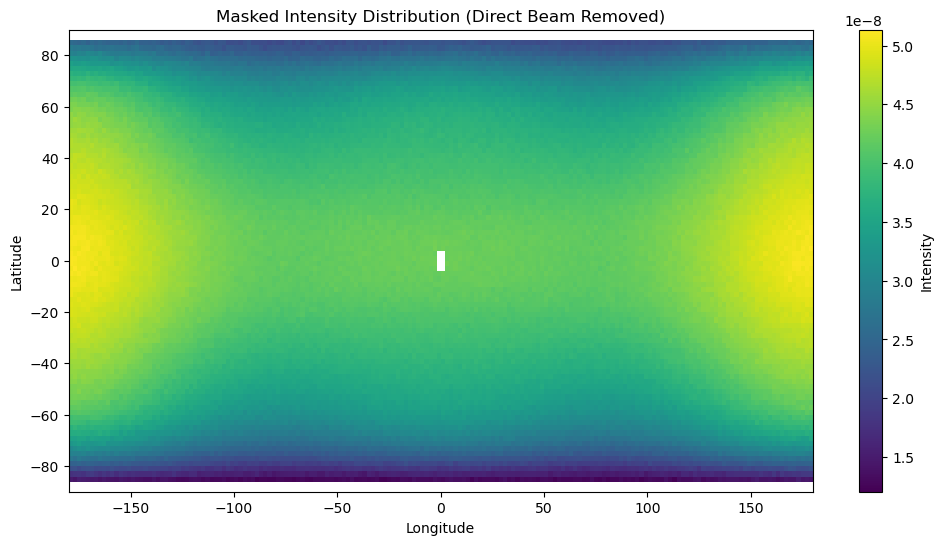

Pole cut: excluding |latitude| > 85.0 deg (last 5.0 deg near each pole)


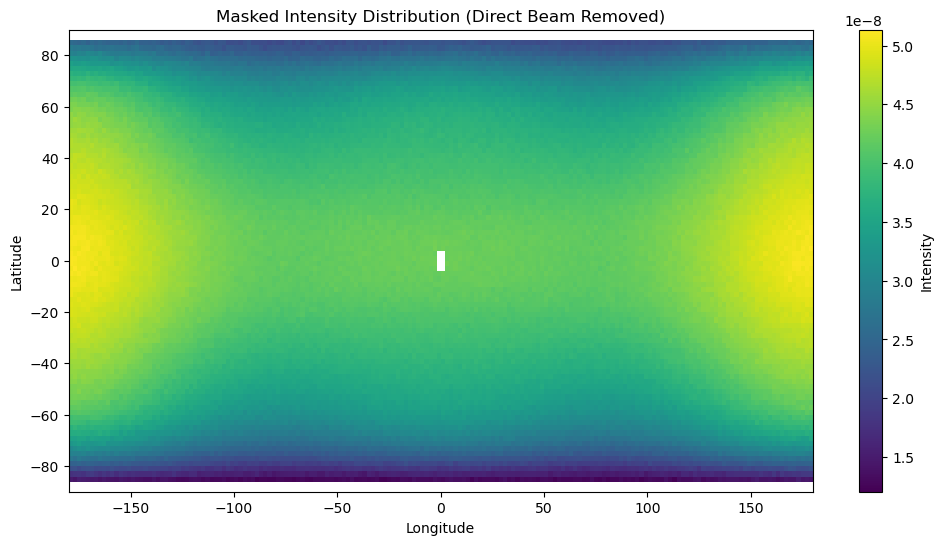

/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_82222/3171122624.py:96: RuntimeWarning: Mean of empty slice
  meridian_cut = np.nanmean(meridian_band, axis=1)
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_82222/3171122624.py:100: RuntimeWarning: invalid value encountered in divide
  np.sqrt(np.nansum(meridian_band_err**2, axis=1)) / meridian_valid_counts,


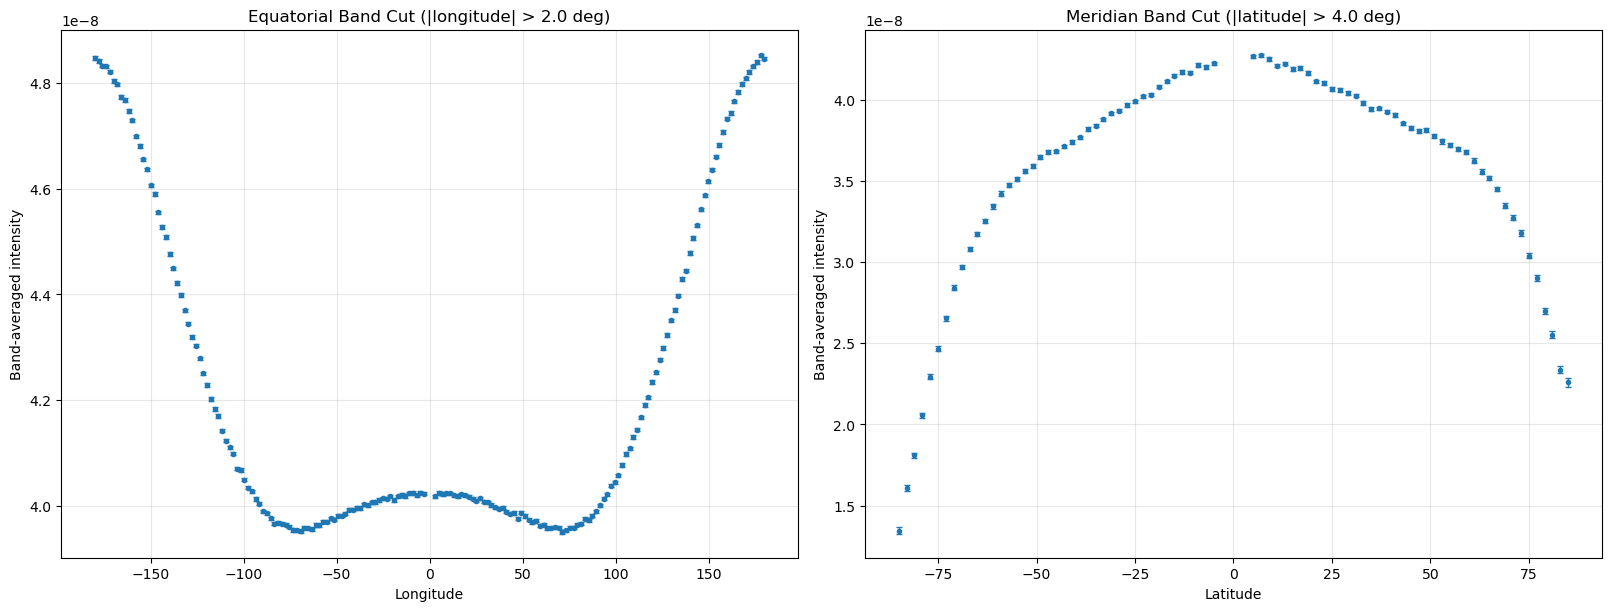

Pole cut: excluding |latitude| > 85.0 deg (last 5.0 deg near each pole)


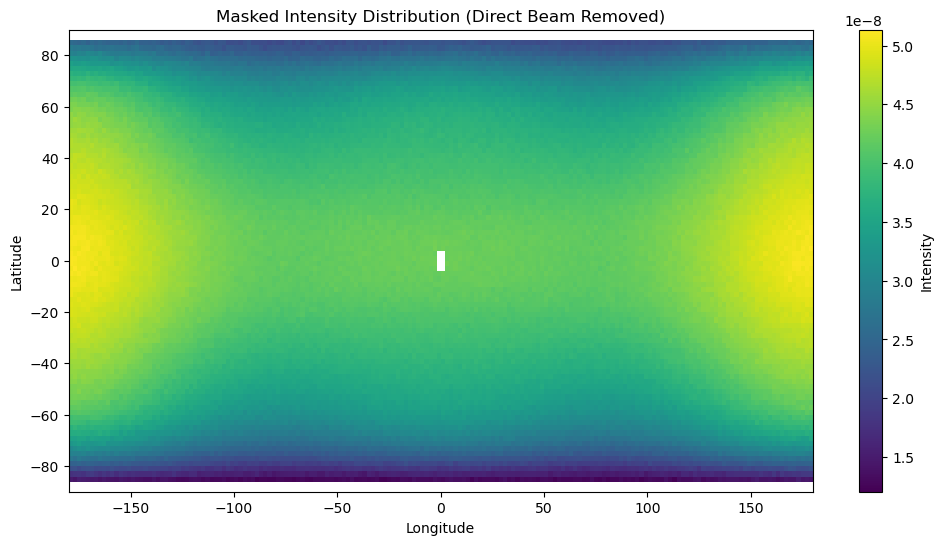

/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_82222/3171122624.py:96: RuntimeWarning: Mean of empty slice
  meridian_cut = np.nanmean(meridian_band, axis=1)
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_82222/3171122624.py:100: RuntimeWarning: invalid value encountered in divide
  np.sqrt(np.nansum(meridian_band_err**2, axis=1)) / meridian_valid_counts,


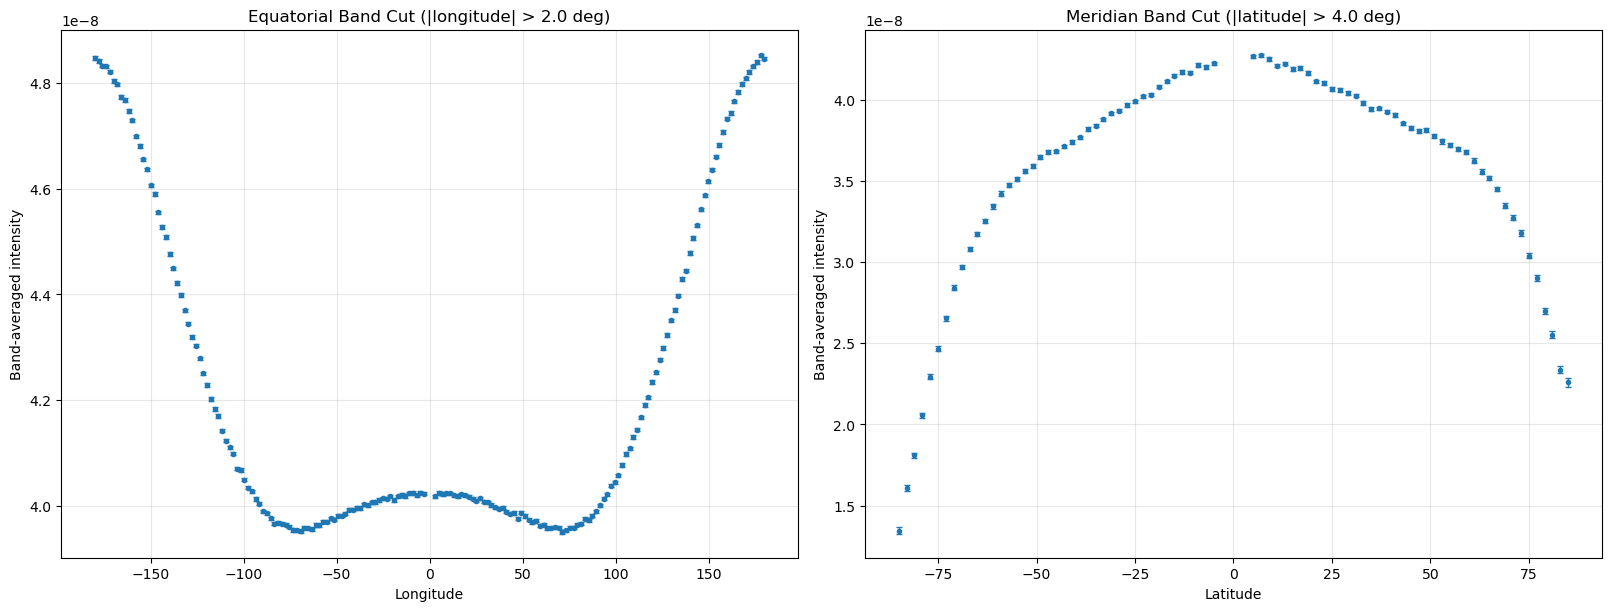

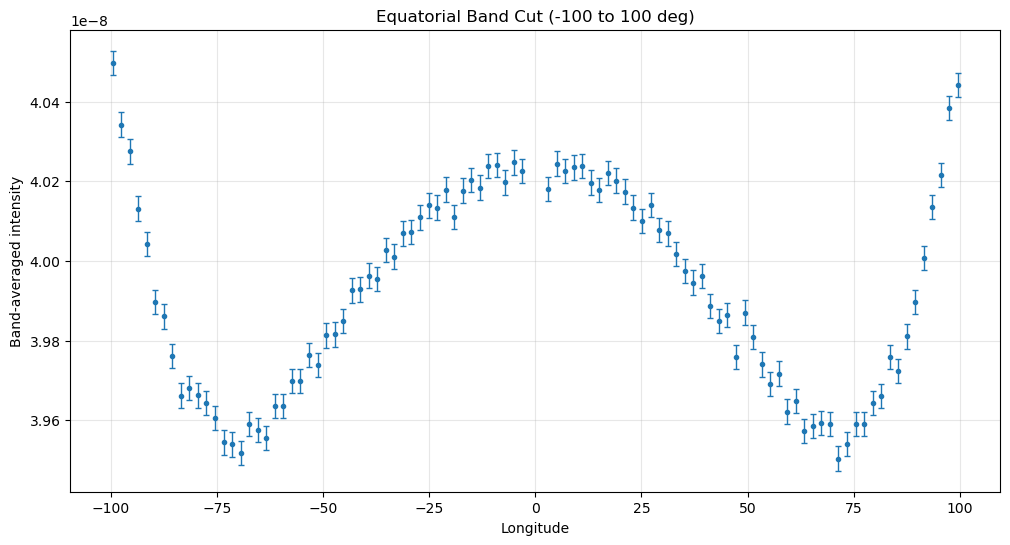

In [110]:
sphere_mon = ms.load_data("/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1to3_r15mmh4cm_bathed_1e9/8")[2]  # adjust index if needed
meta = sphere_mon.metadata
hits = sphere_mon.Intensity
hits_err = sphere_mon.Error
xmin, xmax, ymin, ymax = meta.limits
extent = [xmin, xmax, ymin, ymax]
Hmc = np.array(hits, copy=True)
Hmc_err = np.array(hits_err, copy=True)

# Ensure the array layout is (latitude, longitude).
if hasattr(meta, "dimension") and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
    Hmc = Hmc.T
    Hmc_err = Hmc_err.T

pole_cut_deg = 5.0
lat_centers = np.linspace(ymin + 0.5 * (ymax - ymin) / Hmc.shape[0], ymax - 0.5 * (ymax - ymin) / Hmc.shape[0], Hmc.shape[0])
cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
pole_mask = np.abs(lat_centers) <= (90.0 - pole_cut_deg)
print(f"Pole cut: excluding |latitude| > {90.0 - pole_cut_deg:.1f} deg (last {pole_cut_deg:.1f} deg near each pole)")

safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
Hmc_corrected = Hmc / safe_cos
Hmc_err_corrected = Hmc_err / safe_cos
Hmc_corrected = np.where(pole_mask[:, np.newaxis], Hmc_corrected, np.nan)
Hmc_err_corrected = np.where(pole_mask[:, np.newaxis], Hmc_err_corrected, np.nan)

# ------------------------------------------------------------
# Define angular grid
# ------------------------------------------------------------
lon = np.linspace(xmin, xmax, Hmc_corrected.shape[1])
lat = lat_centers
Lon, Lat = np.meshgrid(lon, lat)

# ------------------------------------------------------------
# Beam mask (from your calibration)
# ------------------------------------------------------------
beam_lon_halfwidth_deg = 2.0
beam_lat_halfwidth_deg = 4.0

beam_mask = (
    (np.abs(Lon) <= beam_lon_halfwidth_deg) &
    (np.abs(Lat) <= beam_lat_halfwidth_deg)
)

# Combine with pole mask
full_mask = pole_mask[:, np.newaxis] & (~beam_mask)

# ------------------------------------------------------------
# Apply mask to corrected data
# ------------------------------------------------------------
Hmc_masked = np.where(full_mask, Hmc_corrected, np.nan)
Hmc_err_masked = np.where(full_mask, Hmc_err_corrected, np.nan)

# ------------------------------------------------------------
# Plot masked map
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.imshow(Hmc_masked, extent=extent, origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Masked Intensity Distribution (Direct Beam Removed)')
plt.show()

# ------------------------------------------------------------
# Equator band cut (mask-aware)
# ------------------------------------------------------------
equator_band_halfwidth = 50.0  # degrees
equator_band_mask = np.abs(lat) <= equator_band_halfwidth

equator_band = Hmc_masked[equator_band_mask, :]
equator_band_err = Hmc_err_masked[equator_band_mask, :]

equator_cut = np.nanmean(equator_band, axis=0)
valid_counts = np.sum(~np.isnan(equator_band), axis=0)
equator_cut_err = np.where(
    valid_counts > 0,
    np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
    np.nan,
)
valid_cols = (valid_counts > 0) & (np.abs(lon) > beam_lon_halfwidth_deg)

lon_plot = lon[valid_cols]
equator_cut_plot = equator_cut[valid_cols]
equator_cut_err_plot = equator_cut_err[valid_cols]

# ------------------------------------------------------------
# Meridian band cut (mask-aware)
# ------------------------------------------------------------
meridian_band_halfwidth = 5.0  # degrees around longitude = 0
meridian_band_mask = np.abs(lon) <= meridian_band_halfwidth

meridian_band = Hmc_masked[:, meridian_band_mask]
meridian_band_err = Hmc_err_masked[:, meridian_band_mask]

meridian_cut = np.nanmean(meridian_band, axis=1)
meridian_valid_counts = np.sum(~np.isnan(meridian_band), axis=1)
meridian_cut_err = np.where(
    meridian_valid_counts > 0,
    np.sqrt(np.nansum(meridian_band_err**2, axis=1)) / meridian_valid_counts,
    np.nan,
)
valid_rows = (meridian_valid_counts > 0) & (np.abs(lat) > beam_lat_halfwidth_deg)

lat_plot = lat[valid_rows]
meridian_cut_plot = meridian_cut[valid_rows]
meridian_cut_err_plot = meridian_cut_err[valid_rows]

fig, axs = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

axs[0].errorbar(lon_plot, equator_cut_plot, yerr=equator_cut_err_plot,
                fmt='o', ms=3, elinewidth=1, capsize=2)
axs[0].set_xlabel('Longitude')
axs[0].set_ylabel('Band-averaged intensity')
axs[0].set_title(f'Equatorial Band Cut (|longitude| > {beam_lon_halfwidth_deg:.1f} deg)')
axs[0].grid(True, alpha=0.3)

axs[1].errorbar(lat_plot, meridian_cut_plot, yerr=meridian_cut_err_plot,
                fmt='o', ms=3, elinewidth=1, capsize=2)
axs[1].set_xlabel('Latitude')
axs[1].set_ylabel('Band-averaged intensity')
axs[1].set_title(f'Meridian Band Cut (|latitude| > {beam_lat_halfwidth_deg:.1f} deg)')
axs[1].grid(True, alpha=0.3)

plt.show()

# ------------------------------------------------------------
# Zoomed equator band cut from -100 to 100 degrees
# ------------------------------------------------------------
equator_zoom_mask = (lon_plot >= -100.0) & (lon_plot <= 100.0)

plt.figure(figsize=(12, 6))
plt.errorbar(
    lon_plot[equator_zoom_mask],
    equator_cut_plot[equator_zoom_mask],
    yerr=equator_cut_err_plot[equator_zoom_mask],
    fmt='o',
    ms=3,
    elinewidth=1,
    capsize=2,
)
plt.xlabel('Longitude')
plt.ylabel('Band-averaged intensity')
plt.title('Equatorial Band Cut (-100 to 100 deg)')
plt.grid(True, alpha=0.3)
plt.show()


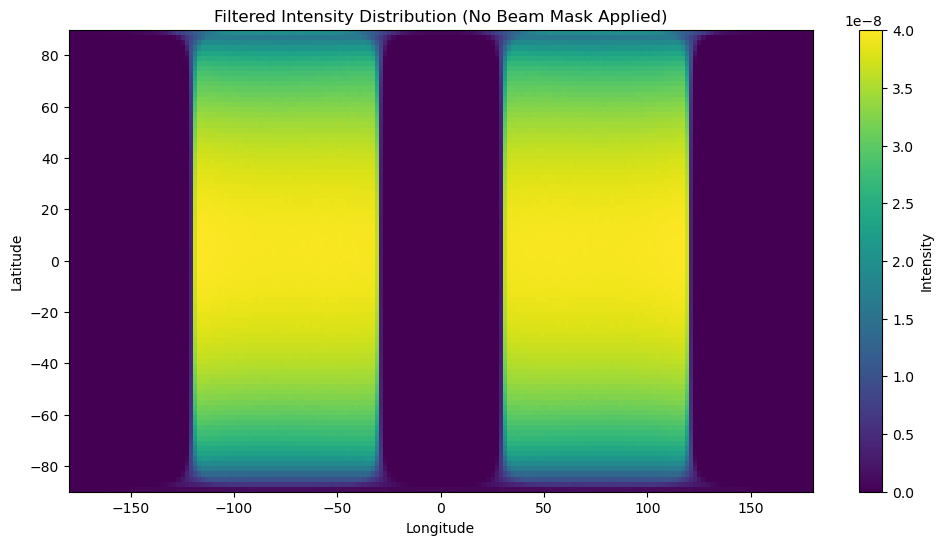

Low outlier cut: removing equator-cut points below 3.543e-08


/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_82222/387296082.py:46: RuntimeWarning: Mean of empty slice
  equator_cut = np.nanmean(equator_band_nonzero, axis=0)
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_82222/387296082.py:50: RuntimeWarning: invalid value encountered in divide
  np.sqrt(np.nansum(equator_band_err_nonzero**2, axis=0)) / valid_counts,


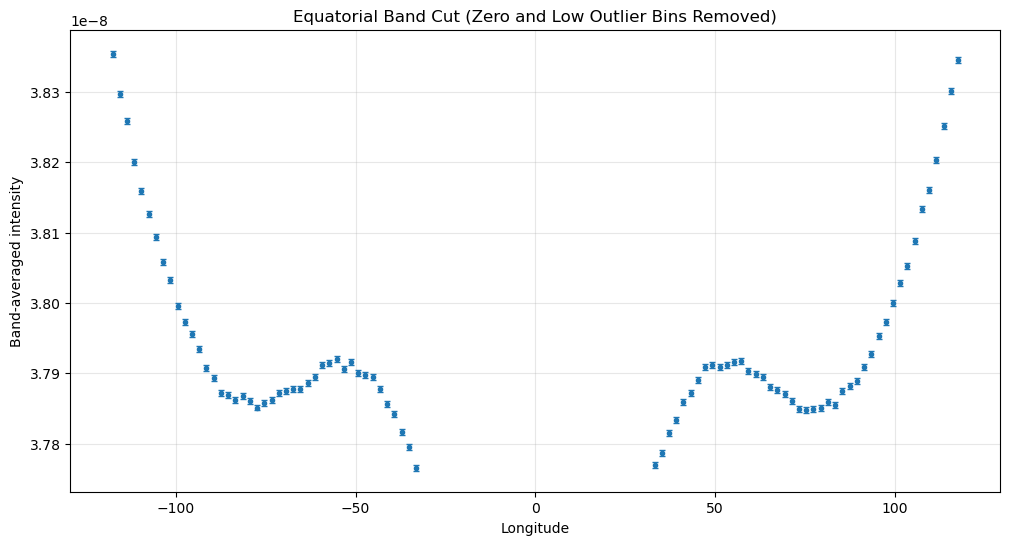

In [97]:
# Plot filtered McStas output without applying a beam mask.
# Zero bins from the McStas angular filter are removed from the equator cut.
sphere_mon = ms.load_data('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/nolid_1e11')[0]  # adjust path/index if needed
sphere_mon = ms.load_data('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1p75to1p85_1e11/2')[0]  # adjust path/index if needed
meta = sphere_mon.metadata
Hmc = np.array(sphere_mon.Intensity, copy=True)
Hmc_err = np.array(sphere_mon.Error, copy=True)
xmin, xmax, ymin, ymax = meta.limits
extent = [xmin, xmax, ymin, ymax]

if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
    Hmc = Hmc.T
    Hmc_err = Hmc_err.T

lat_centers = np.linspace(
    ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
    ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
    Hmc.shape[0],
)
lon = np.linspace(xmin, xmax, Hmc.shape[1])

cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)

Hmc_corrected = Hmc / safe_cos
Hmc_err_corrected = Hmc_err / safe_cos

plt.figure(figsize=(12, 6))
plt.imshow(Hmc_corrected, extent=extent, origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Filtered Intensity Distribution (No Beam Mask Applied)')
plt.show()

equator_band_halfwidth = 50.0  # degrees
equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth
equator_band = Hmc_corrected[equator_band_mask, :]
equator_band_err = Hmc_err_corrected[equator_band_mask, :]

# Remove zero bins from the band average; these are outside the McStas angular filter.
nonzero_band = equator_band > 0
equator_band_nonzero = np.where(nonzero_band, equator_band, np.nan)
equator_band_err_nonzero = np.where(nonzero_band, equator_band_err, np.nan)

equator_cut = np.nanmean(equator_band_nonzero, axis=0)
valid_counts = np.sum(~np.isnan(equator_band_nonzero), axis=0)
equator_cut_err = np.where(
    valid_counts > 0,
    np.sqrt(np.nansum(equator_band_err_nonzero**2, axis=0)) / valid_counts,
    np.nan,
)

# Remove low outlier columns caused by partially filled angular-filter edge bins.
valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
low_outlier_threshold = 0.935 * np.nanmedian(equator_cut[valid_cols])
valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)
print(f"Low outlier cut: removing equator-cut points below {low_outlier_threshold:.3e}")

plt.figure(figsize=(12, 6))
plt.errorbar(
    lon[valid_cols],
    equator_cut[valid_cols],
    yerr=equator_cut_err[valid_cols],
    fmt='o',
    ms=3,
    elinewidth=1,
    capsize=2,
)
plt.xlabel('Longitude')
plt.ylabel('Band-averaged intensity')
plt.title('Equatorial Band Cut (Zero and Low Outlier Bins Removed)')
plt.grid(True, alpha=0.3)
plt.show()


run 8: thickness=0.900 mm, const=3.760485e-09 +/- 2.461985e-13, weighted_rms=2.173517e-12, red_chi2=1.321, n=60
run 9: thickness=0.950 mm, const=3.897877e-09 +/- 2.504285e-13, weighted_rms=2.223396e-12, red_chi2=1.336, n=60
run 10: thickness=1.000 mm, const=4.029735e-09 +/- 2.544044e-13, weighted_rms=2.297069e-12, red_chi2=1.382, n=60
run 0: thickness=0.500 mm, const=2.433967e-09 +/- 1.997220e-13, weighted_rms=1.950600e-12, red_chi2=1.617, n=60
run 7: thickness=0.850 mm, const=3.617513e-09 +/- 2.416988e-13, weighted_rms=2.403569e-12, red_chi2=1.676, n=60
run 11: thickness=1.050 mm, const=4.156581e-09 +/- 2.581557e-13, weighted_rms=2.700080e-12, red_chi2=1.854, n=60
run 12: thickness=1.100 mm, const=4.278347e-09 +/- 2.616891e-13, weighted_rms=2.913002e-12, red_chi2=2.100, n=60
run 1: thickness=0.550 mm, const=2.624280e-09 +/- 2.071392e-13, weighted_rms=2.406247e-12, red_chi2=2.287, n=60
run 2: thickness=0.600 mm, const=2.806330e-09 +/- 2.139679e-13, weighted_rms=2.511016e-12, red_chi2=2

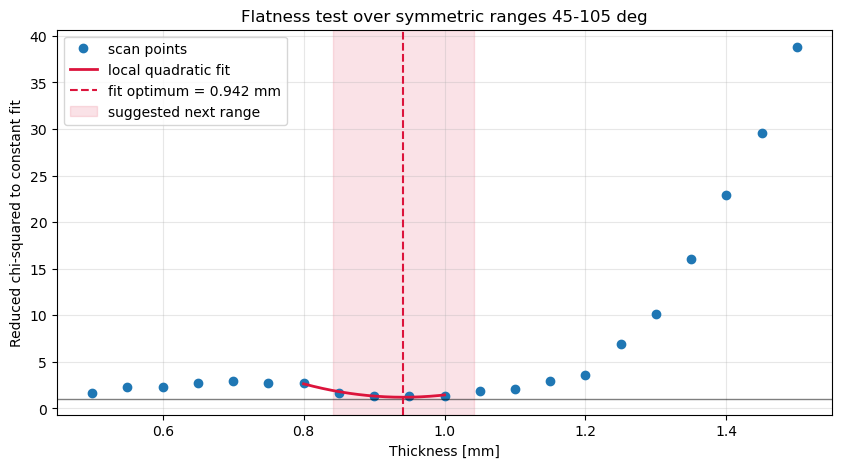

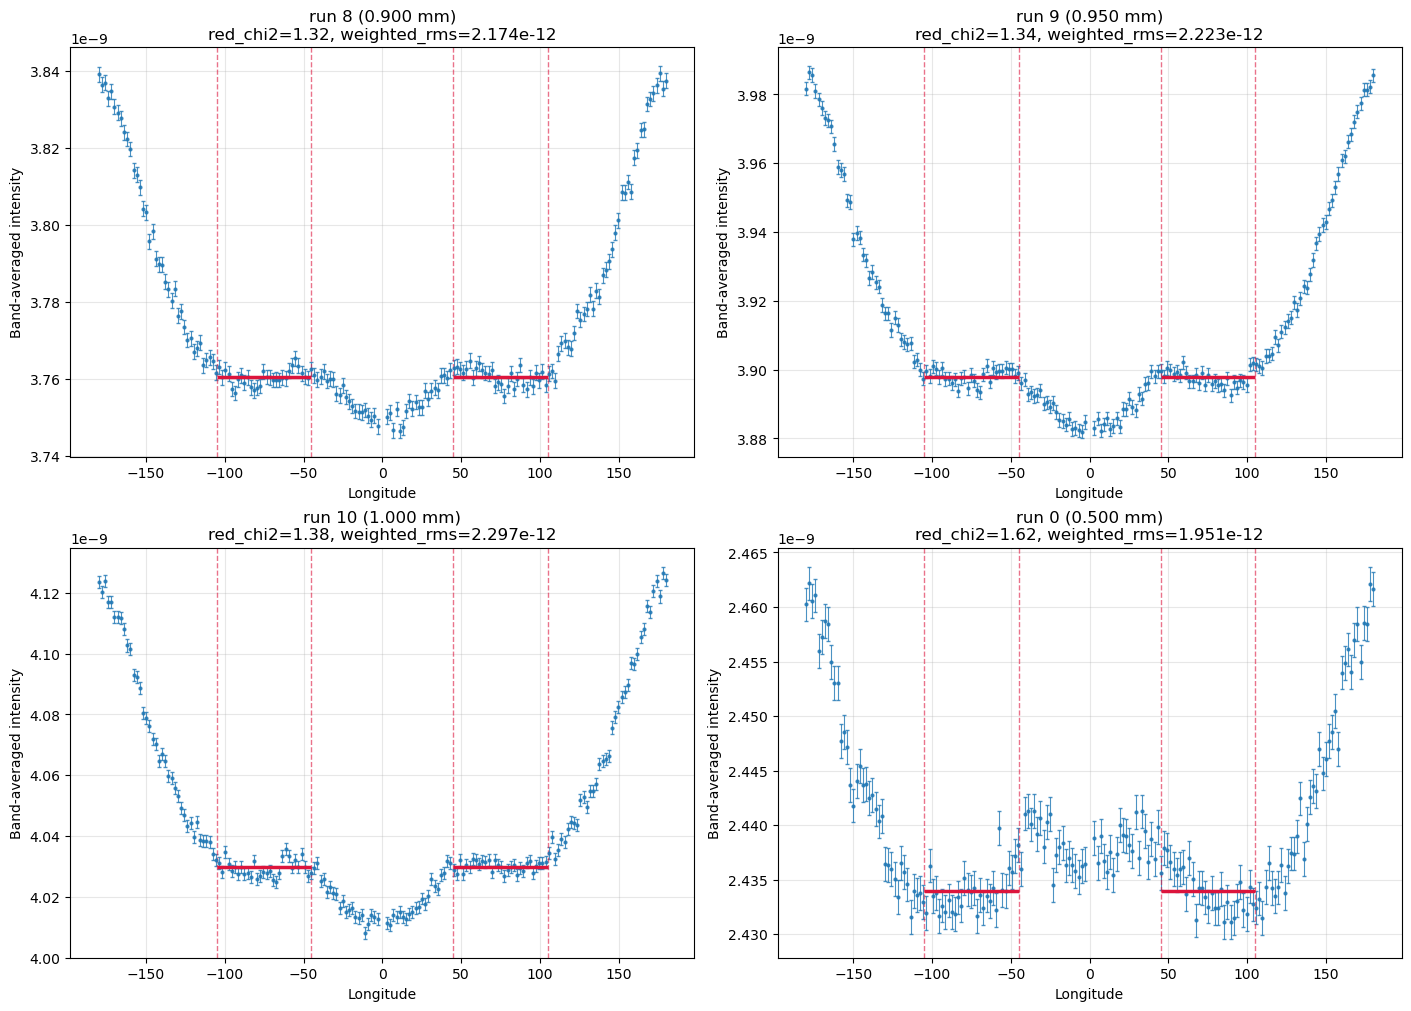

In [98]:
# Flatness test of thickness-scan equatorial cuts using symmetric side windows
fit_min_deg = 45.0
fit_max_deg = 105.0
scan_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/0p5to1p5_r5mmh4cm_bathed_1e10')
run_indices = list(range(21))
thicknesses_mm = np.linspace(0.5, 1.5, len(run_indices))
results = []

for run_idx, thickness_mm in zip(run_indices, thicknesses_mm):
    sphere_mon = ms.load_data(str(scan_root / str(run_idx)))[0]
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])
    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)

    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos
    pole_mask = np.abs(lat_centers) <= (90.0 - pole_cut_deg)
    Hmc_corrected = np.where(pole_mask[:, np.newaxis], Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(pole_mask[:, np.newaxis], Hmc_err_corrected, np.nan)

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_mask = (np.abs(Lon) <= beam_lon_halfwidth_deg) & (np.abs(Lat) <= beam_lat_halfwidth_deg)
    full_mask = pole_mask[:, np.newaxis] & (~beam_mask)
    Hmc_masked = np.where(full_mask, Hmc_corrected, np.nan)
    Hmc_err_masked = np.where(full_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth
    equator_band = Hmc_masked[equator_band_mask, :]
    equator_band_err = Hmc_err_masked[equator_band_mask, :]

    equator_cut = np.nanmean(equator_band, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
        np.nan,
    )

    valid_cols = (valid_counts > 0) & (np.abs(lon) > beam_lon_halfwidth_deg)
    fit_mask = valid_cols & (((lon >= fit_min_deg) & (lon <= fit_max_deg)) | ((lon >= -fit_max_deg) & (lon <= -fit_min_deg)))

    x = lon[fit_mask]
    y = equator_cut[fit_mask]
    sigma = equator_cut_err[fit_mask]

    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma) & (sigma > 0)
    x = x[finite]
    y = y[finite]
    sigma = sigma[finite]

    if len(x) < 2:
        continue

    weights = 1.0 / sigma**2
    const = np.sum(weights * y) / np.sum(weights)
    const_err = np.sqrt(1.0 / np.sum(weights))
    residuals = y - const
    chi2 = np.sum((residuals / sigma) ** 2)
    ndof = len(y) - 1
    red_chi2 = chi2 / ndof if ndof > 0 else np.nan
    weighted_rms = np.sqrt(np.sum(weights * residuals**2) / np.sum(weights))

    results.append({
        'run_idx': run_idx,
        'thickness_mm': thickness_mm,
        'const': const,
        'const_err': const_err,
        'weighted_rms': weighted_rms,
        'chi2': chi2,
        'red_chi2': red_chi2,
        'n_points': len(x),
        'fit_x': x,
        'fit_y': y,
        'fit_sigma': sigma,
        'lon_plot': lon[valid_cols],
        'equator_cut_plot': equator_cut[valid_cols],
        'equator_cut_err_plot': equator_cut_err[valid_cols],
    })

results = sorted(results, key=lambda r: abs(r['red_chi2'] - 1.0))

for r in results:
    print(
        f"run {r['run_idx']}: thickness={r['thickness_mm']:.3f} mm, "
        f"const={r['const']:.6e} +/- {r['const_err']:.6e}, "
        f"weighted_rms={r['weighted_rms']:.6e}, red_chi2={r['red_chi2']:.3f}, n={r['n_points']}"
    )

best = results[0]
print('')
print(
    f"Flattest in symmetric ranges [-{fit_max_deg:.0f}, -{fit_min_deg:.0f}] and [{fit_min_deg:.0f}, {fit_max_deg:.0f}] deg: "
    f"run {best['run_idx']} ({best['thickness_mm']:.3f} mm), red_chi2={best['red_chi2']:.3f}, weighted_rms={best['weighted_rms']:.6e}"
)

thickness_all = np.array([r['thickness_mm'] for r in results])
red_chi2_all = np.array([r['red_chi2'] for r in results])
order = np.argsort(thickness_all)
thickness_sorted = thickness_all[order]
red_chi2_sorted = red_chi2_all[order]

best_idx_sorted = int(np.nanargmin(red_chi2_sorted))
fit_window_half_width_mm = 0.15
local_fit_mask = np.abs(thickness_sorted - thickness_sorted[best_idx_sorted]) <= fit_window_half_width_mm

if np.sum(local_fit_mask) < 3:
    local_fit_mask = np.zeros_like(thickness_sorted, dtype=bool)
    lo = max(best_idx_sorted - 1, 0)
    hi = min(best_idx_sorted + 2, len(thickness_sorted))
    local_fit_mask[lo:hi] = True

quad_coeff = np.polyfit(thickness_sorted[local_fit_mask], red_chi2_sorted[local_fit_mask], 2)
a_quad, b_quad, c_quad = quad_coeff
best_thickness_fit = -b_quad / (2 * a_quad) if a_quad > 0 else np.nan
best_red_chi2_fit = np.polyval(quad_coeff, best_thickness_fit) if np.isfinite(best_thickness_fit) else np.nan

suggested_half_width_mm = 0.10
suggested_min = best_thickness_fit - suggested_half_width_mm
suggested_max = best_thickness_fit + suggested_half_width_mm
print(
    f"Quadratic local fit optimum: thickness={best_thickness_fit:.4f} mm, "
    f"red_chi2={best_red_chi2_fit:.3f}"
)
print(f"Suggested next scan range: {suggested_min:.3f} to {suggested_max:.3f} mm")

fit_x = np.linspace(np.nanmin(thickness_sorted[local_fit_mask]), np.nanmax(thickness_sorted[local_fit_mask]), 300)
fit_y = np.polyval(quad_coeff, fit_x)

plt.figure(figsize=(10, 5))
plt.plot(thickness_sorted, red_chi2_sorted, 'o', label='scan points')
plt.plot(fit_x, fit_y, color='crimson', lw=2, label='local quadratic fit')
plt.axhline(1.0, color='k', lw=1, alpha=0.5)
plt.axvline(best_thickness_fit, color='crimson', lw=1.5, ls='--', label=f'fit optimum = {best_thickness_fit:.3f} mm')
plt.axvspan(suggested_min, suggested_max, color='crimson', alpha=0.12, label='suggested next range')
plt.xlabel('Thickness [mm]')
plt.ylabel('Reduced chi-squared to constant fit')
plt.title(f'Flatness test over symmetric ranges {fit_min_deg:.0f}-{fit_max_deg:.0f} deg')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

best_four = results[:4]
fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axs = axs.ravel()

for ax, r in zip(axs, best_four):
    ax.errorbar(
        r['lon_plot'],
        r['equator_cut_plot'],
        yerr=r['equator_cut_err_plot'],
        fmt='o',
        ms=2,
        elinewidth=0.8,
        capsize=1.5,
        alpha=0.8,
    )
    ax.hlines(r['const'], fit_min_deg, fit_max_deg, color='crimson', lw=2.5, zorder=5)
    ax.hlines(r['const'], -fit_max_deg, -fit_min_deg, color='crimson', lw=2.5, zorder=5)
    ax.axvline(fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(-fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(-fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Band-averaged intensity')
    ax.set_title(
        f"run {r['run_idx']} ({r['thickness_mm']:.3f} mm)\n"
        f"red_chi2={r['red_chi2']:.2f}, weighted_rms={r['weighted_rms']:.3e}"
    )
    ax.grid(True, alpha=0.3)

plt.show()


run 1: thickness=1.783 mm, const=3.756588e-08 +/- 5.471861e-13, weighted_rms=2.766904e-11, red_chi2=43.338, n=60, low_cut=3.570e-08
run 0: thickness=1.750 mm, const=3.724189e-08 +/- 5.450868e-13, weighted_rms=2.987721e-11, red_chi2=50.921, n=60, low_cut=3.539e-08
run 2: thickness=1.817 mm, const=3.787801e-08 +/- 5.491884e-13, weighted_rms=3.121784e-11, red_chi2=54.766, n=60, low_cut=3.600e-08
run 3: thickness=1.850 mm, const=3.818411e-08 +/- 5.511402e-13, weighted_rms=3.470747e-11, red_chi2=67.216, n=60, low_cut=3.629e-08

Flattest filtered run in symmetric ranges [-95, -35] and [35, 95] deg: run 1 (1.783 mm), red_chi2=43.338, weighted_rms=2.766904e-11


/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_82222/2232553087.py:46: RuntimeWarning: Mean of empty slice
  equator_cut = np.nanmean(equator_band_nonzero, axis=0)
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_82222/2232553087.py:50: RuntimeWarning: invalid value encountered in divide
  np.sqrt(np.nansum(equator_band_err_nonzero**2, axis=0)) / valid_counts,


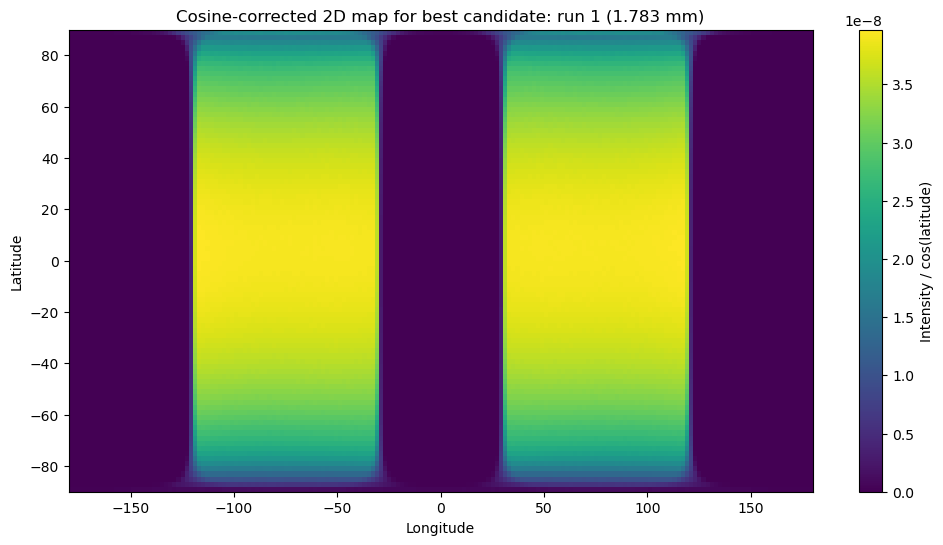

Quadratic local fit optimum: thickness=1.7799 mm, red_chi2=45.984
Suggested next scan range: 1.770 to 1.790 mm


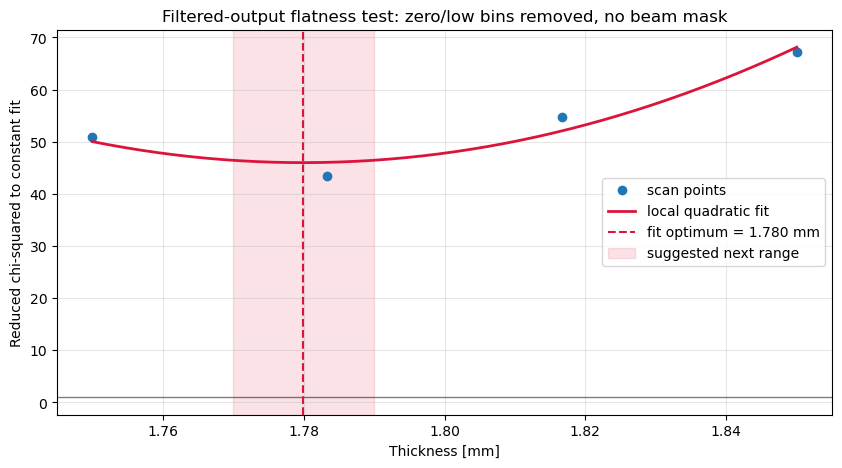

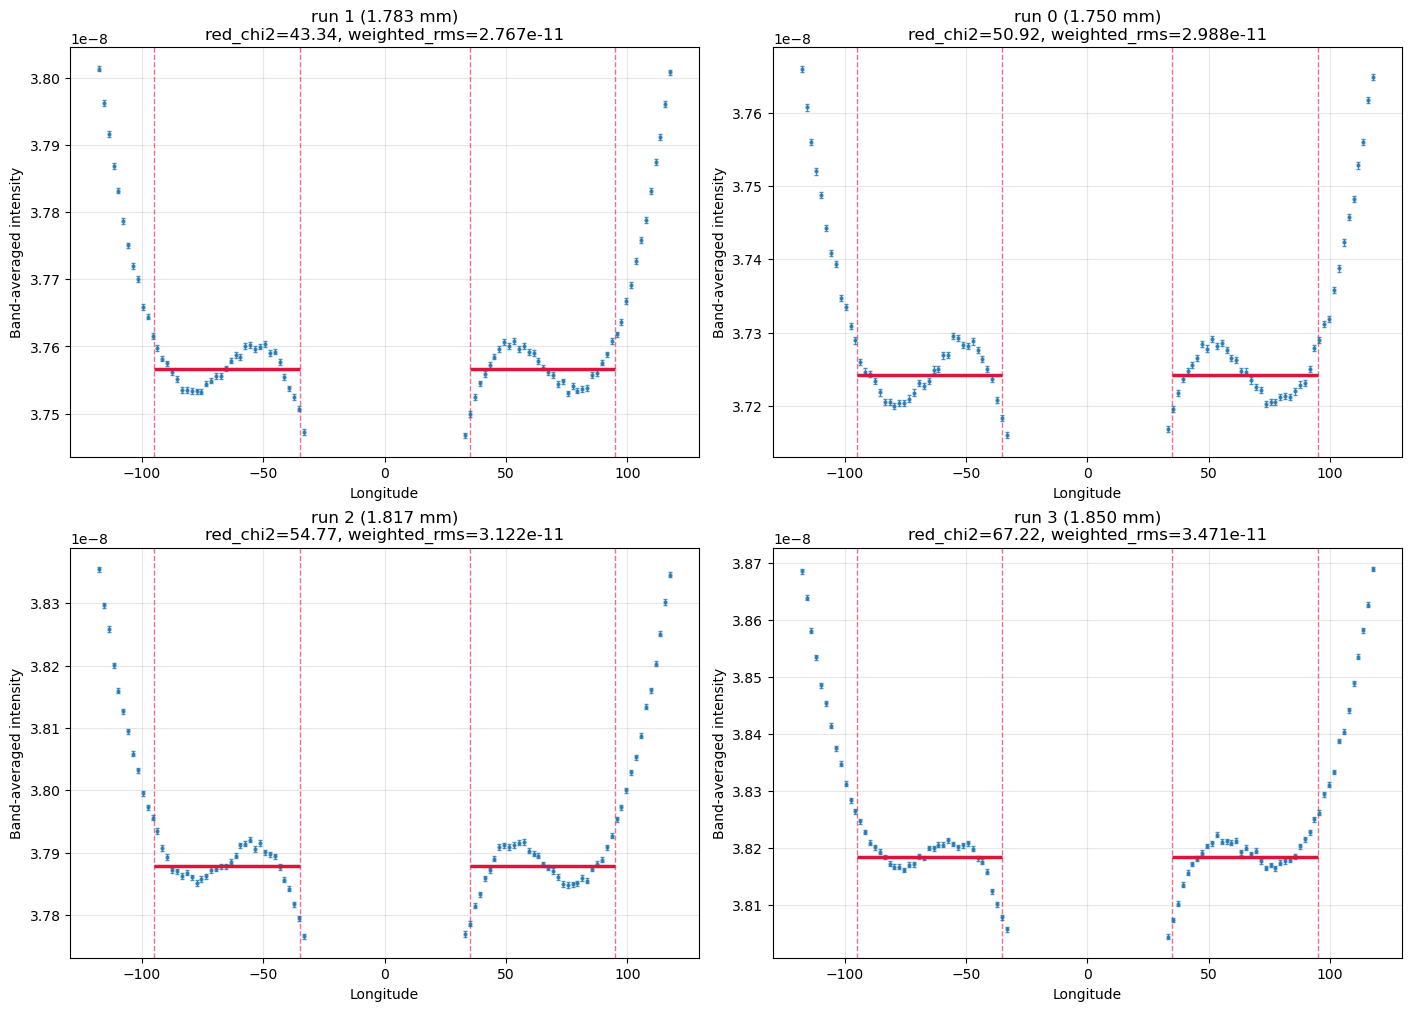

In [99]:
# Thickness estimation using McStas angular-filtered output.
# No beamstop mask and no pole cut are applied here.
# Zero bins and low edge outliers are removed before the flatness test.
fit_min_deg = 35.0
fit_max_deg = 95.0
scan_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1p75to1p85_1e11')
run_indices = list(range(4))
thicknesses_mm = np.linspace(1.75, 1.85, len(run_indices))
low_outlier_fraction = 0.95
fit_window_half_width_mm = 0.1
suggested_half_width_mm = 0.01
results_filtered = []

for run_idx, thickness_mm in zip(run_indices, thicknesses_mm):
    sphere_mon = ms.load_data(str(scan_root / str(run_idx)))[0]
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth
    equator_band = Hmc_corrected[equator_band_mask, :]
    equator_band_err = Hmc_err_corrected[equator_band_mask, :]

    # Remove zero bins produced by the McStas angular filter before averaging.
    nonzero_band = equator_band > 0
    equator_band_nonzero = np.where(nonzero_band, equator_band, np.nan)
    equator_band_err_nonzero = np.where(nonzero_band, equator_band_err, np.nan)

    equator_cut = np.nanmean(equator_band_nonzero, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band_nonzero), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err_nonzero**2, axis=0)) / valid_counts,
        np.nan,
    )

    # Remove low outlier columns caused by partially filled filter-edge bins.
    valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
    low_outlier_threshold = low_outlier_fraction * np.nanmedian(equator_cut[valid_cols])
    valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)

    fit_mask = valid_cols & (((lon >= fit_min_deg) & (lon <= fit_max_deg)) | ((lon >= -fit_max_deg) & (lon <= -fit_min_deg)))
    x = lon[fit_mask]
    y = equator_cut[fit_mask]
    sigma = equator_cut_err[fit_mask]

    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma) & (sigma > 0)
    x = x[finite]
    y = y[finite]
    sigma = sigma[finite]

    if len(x) < 2:
        continue

    weights = 1.0 / sigma**2
    const = np.sum(weights * y) / np.sum(weights)
    const_err = np.sqrt(1.0 / np.sum(weights))
    residuals = y - const
    chi2 = np.sum((residuals / sigma) ** 2)
    ndof = len(y) - 1
    red_chi2 = chi2 / ndof if ndof > 0 else np.nan
    weighted_rms = np.sqrt(np.sum(weights * residuals**2) / np.sum(weights))

    results_filtered.append({
        'run_idx': run_idx,
        'thickness_mm': thickness_mm,
        'const': const,
        'const_err': const_err,
        'weighted_rms': weighted_rms,
        'chi2': chi2,
        'red_chi2': red_chi2,
        'n_points': len(x),
        'low_outlier_threshold': low_outlier_threshold,
        'map_corrected': Hmc_corrected,
        'map_extent': [xmin, xmax, ymin, ymax],
        'lon_plot': lon[valid_cols],
        'equator_cut_plot': equator_cut[valid_cols],
        'equator_cut_err_plot': equator_cut_err[valid_cols],
    })

results_filtered = sorted(results_filtered, key=lambda r: r['red_chi2'])

for r in results_filtered:
    print(
        f"run {r['run_idx']}: thickness={r['thickness_mm']:.3f} mm, "
        f"const={r['const']:.6e} +/- {r['const_err']:.6e}, "
        f"weighted_rms={r['weighted_rms']:.6e}, red_chi2={r['red_chi2']:.3f}, "
        f"n={r['n_points']}, low_cut={r['low_outlier_threshold']:.3e}"
    )

best = results_filtered[0]
print('')
print(
    f"Flattest filtered run in symmetric ranges [-{fit_max_deg:.0f}, -{fit_min_deg:.0f}] and [{fit_min_deg:.0f}, {fit_max_deg:.0f}] deg: "
    f"run {best['run_idx']} ({best['thickness_mm']:.3f} mm), red_chi2={best['red_chi2']:.3f}, weighted_rms={best['weighted_rms']:.6e}"
)

plt.figure(figsize=(12, 6))
plt.imshow(best['map_corrected'], extent=best['map_extent'], origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Intensity / cos(latitude)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f"Cosine-corrected 2D map for best candidate: run {best['run_idx']} ({best['thickness_mm']:.3f} mm)")
plt.show()

thickness_all = np.array([r['thickness_mm'] for r in results_filtered])
red_chi2_all = np.array([r['red_chi2'] for r in results_filtered])
order = np.argsort(thickness_all)
thickness_sorted = thickness_all[order]
red_chi2_sorted = red_chi2_all[order]

best_idx_sorted = int(np.nanargmin(red_chi2_sorted))

local_fit_mask = np.abs(thickness_sorted - thickness_sorted[best_idx_sorted]) <= fit_window_half_width_mm

if np.sum(local_fit_mask) < 3:
    local_fit_mask = np.zeros_like(thickness_sorted, dtype=bool)
    lo = max(best_idx_sorted - 1, 0)
    hi = min(best_idx_sorted + 2, len(thickness_sorted))
    local_fit_mask[lo:hi] = True

quad_coeff = np.polyfit(thickness_sorted[local_fit_mask], red_chi2_sorted[local_fit_mask], 2)
a_quad, b_quad, c_quad = quad_coeff
best_thickness_fit = -b_quad / (2 * a_quad) if a_quad > 0 else np.nan
best_red_chi2_fit = np.polyval(quad_coeff, best_thickness_fit) if np.isfinite(best_thickness_fit) else np.nan


suggested_min = best_thickness_fit - suggested_half_width_mm
suggested_max = best_thickness_fit + suggested_half_width_mm
print(
    f"Quadratic local fit optimum: thickness={best_thickness_fit:.4f} mm, "
    f"red_chi2={best_red_chi2_fit:.3f}"
)
print(f"Suggested next scan range: {suggested_min:.3f} to {suggested_max:.3f} mm")

fit_x = np.linspace(np.nanmin(thickness_sorted[local_fit_mask]), np.nanmax(thickness_sorted[local_fit_mask]), 300)
fit_y = np.polyval(quad_coeff, fit_x)

plt.figure(figsize=(10, 5))
plt.plot(thickness_sorted, red_chi2_sorted, 'o', label='scan points')
plt.plot(fit_x, fit_y, color='crimson', lw=2, label='local quadratic fit')
plt.axhline(1.0, color='k', lw=1, alpha=0.5)
plt.axvline(best_thickness_fit, color='crimson', lw=1.5, ls='--', label=f'fit optimum = {best_thickness_fit:.3f} mm')
plt.axvspan(suggested_min, suggested_max, color='crimson', alpha=0.12, label='suggested next range')
plt.xlabel('Thickness [mm]')
plt.ylabel('Reduced chi-squared to constant fit')
plt.title('Filtered-output flatness test: zero/low bins removed, no beam mask')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

best_four = results_filtered[:4]
fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axs = axs.ravel()

for ax, r in zip(axs, best_four):
    ax.errorbar(
        r['lon_plot'],
        r['equator_cut_plot'],
        yerr=r['equator_cut_err_plot'],
        fmt='o',
        ms=2,
        elinewidth=0.8,
        capsize=1.5,
        alpha=0.8,
    )
    ax.hlines(r['const'], fit_min_deg, fit_max_deg, color='crimson', lw=2.5, zorder=5)
    ax.hlines(r['const'], -fit_max_deg, -fit_min_deg, color='crimson', lw=2.5, zorder=5)
    ax.axvline(fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(-fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(-fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Band-averaged intensity')
    ax.set_title(
        f"run {r['run_idx']} ({r['thickness_mm']:.3f} mm)\n"
        f"red_chi2={r['red_chi2']:.2f}, weighted_rms={r['weighted_rms']:.3e}"
    )
    ax.grid(True, alpha=0.3)

plt.show()


Beam bathes full sample: best run 0 (1.000 mm), red_chi2=1.775, weighted_rms=5.837539e-12, n=60
Beam avoids lids: best run 0 (1.000 mm), red_chi2=2.117, weighted_rms=4.241414e-12, n=60


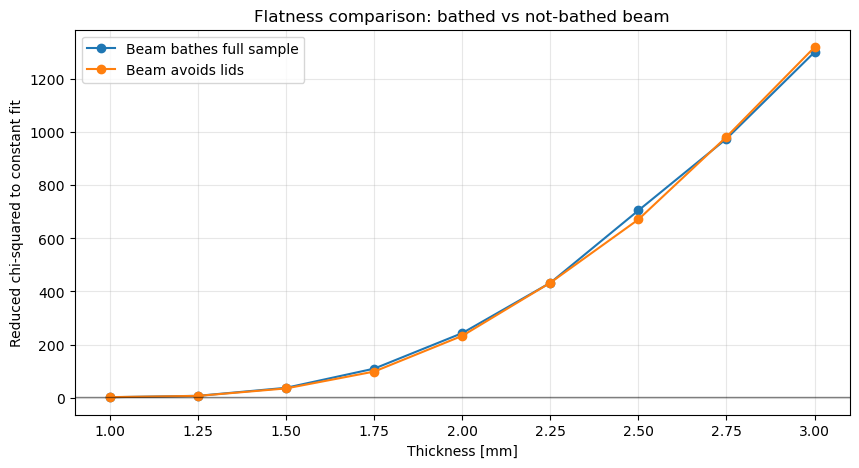

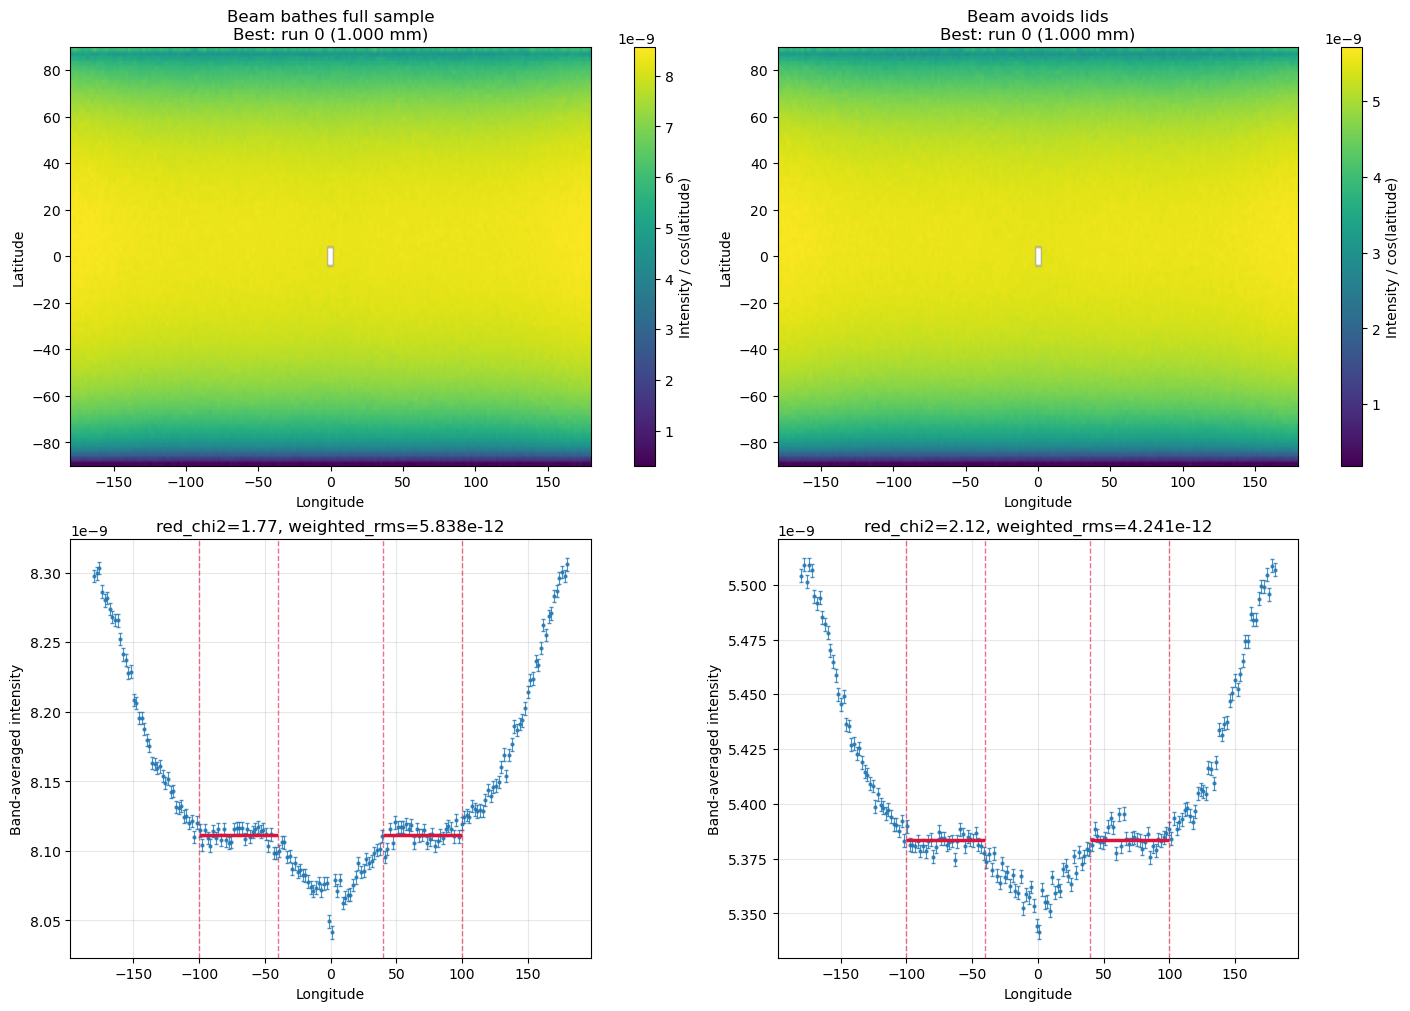

In [100]:
# Compare two thickness scans:
# 1) beam bathes the full sample, including lids
# 2) narrower beam, so the lids are not illuminated
# Uses cosine-corrected maps, beam-center masking, zero-bin removal, and low-outlier rejection.

fit_min_deg = 40.0
fit_max_deg = 100.0
equator_band_halfwidth_local = 50.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0
low_outlier_fraction = 0.8

scan_configs = {
    'bathe': {
        'root': Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1to3_r5mmh5cm_bathed_1e10'),
        'label': 'Beam bathes full sample',
    },
    'notbathed': {
        'root': Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1to3_r5mmh5cm_notbathed_1e10'),
        'label': 'Beam avoids lids',
    },
}

run_indices = list(range(9))
thicknesses_mm = np.linspace(1.0, 3.0, len(run_indices))

def analyze_scan(scan_root):
    results = []

    for run_idx, thickness_mm in zip(run_indices, thicknesses_mm):
        sphere_mon = ms.load_data(str(scan_root / str(run_idx)))[0]
        meta = sphere_mon.metadata
        Hmc = np.array(sphere_mon.Intensity, copy=True)
        Hmc_err = np.array(sphere_mon.Error, copy=True)

        if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
            Hmc = Hmc.T
            Hmc_err = Hmc_err.T

        xmin, xmax, ymin, ymax = meta.limits
        extent = [xmin, xmax, ymin, ymax]
        lat_centers = np.linspace(
            ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
            ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
            Hmc.shape[0],
        )
        lon = np.linspace(xmin, xmax, Hmc.shape[1])

        cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
        safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
        Hmc_corrected = Hmc / safe_cos
        Hmc_err_corrected = Hmc_err / safe_cos

        Lon, Lat = np.meshgrid(lon, lat_centers)
        beam_center_mask = (
            (np.abs(Lon) <= beam_lon_halfwidth_deg_local) &
            (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
        )
        Hmc_masked = np.where(~beam_center_mask, Hmc_corrected, np.nan)
        Hmc_err_masked = np.where(~beam_center_mask, Hmc_err_corrected, np.nan)

        equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth_local
        equator_band = Hmc_masked[equator_band_mask, :]
        equator_band_err = Hmc_err_masked[equator_band_mask, :]

        nonzero_band = equator_band > 0
        equator_band_nonzero = np.where(nonzero_band, equator_band, np.nan)
        equator_band_err_nonzero = np.where(nonzero_band, equator_band_err, np.nan)

        equator_cut = np.nanmean(equator_band_nonzero, axis=0)
        valid_counts = np.sum(~np.isnan(equator_band_nonzero), axis=0)
        equator_cut_err = np.where(
            valid_counts > 0,
            np.sqrt(np.nansum(equator_band_err_nonzero**2, axis=0)) / valid_counts,
            np.nan,
        )

        valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
        low_outlier_threshold = low_outlier_fraction * np.nanmedian(equator_cut[valid_cols])
        valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)

        fit_mask = valid_cols & (((lon >= fit_min_deg) & (lon <= fit_max_deg)) | ((lon >= -fit_max_deg) & (lon <= -fit_min_deg)))
        x = lon[fit_mask]
        y = equator_cut[fit_mask]
        sigma = equator_cut_err[fit_mask]

        finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma) & (sigma > 0)
        x = x[finite]
        y = y[finite]
        sigma = sigma[finite]

        if len(x) < 2:
            continue

        weights = 1.0 / sigma**2
        const = np.sum(weights * y) / np.sum(weights)
        const_err = np.sqrt(1.0 / np.sum(weights))
        residuals = y - const
        chi2 = np.sum((residuals / sigma) ** 2)
        ndof = len(y) - 1
        red_chi2 = chi2 / ndof if ndof > 0 else np.nan
        weighted_rms = np.sqrt(np.sum(weights * residuals**2) / np.sum(weights))

        results.append({
            'run_idx': run_idx,
            'thickness_mm': thickness_mm,
            'const': const,
            'const_err': const_err,
            'weighted_rms': weighted_rms,
            'red_chi2': red_chi2,
            'n_points': len(x),
            'map_corrected': Hmc_masked,
            'map_extent': extent,
            'lon_plot': lon[valid_cols],
            'equator_cut_plot': equator_cut[valid_cols],
            'equator_cut_err_plot': equator_cut_err[valid_cols],
        })

    return sorted(results, key=lambda r: r['red_chi2'])

analysis = {name: analyze_scan(cfg['root']) for name, cfg in scan_configs.items()}

for name, cfg in scan_configs.items():
    best = analysis[name][0]
    print(
        f"{cfg['label']}: best run {best['run_idx']} ({best['thickness_mm']:.3f} mm), "
        f"red_chi2={best['red_chi2']:.3f}, weighted_rms={best['weighted_rms']:.6e}, n={best['n_points']}"
    )

plt.figure(figsize=(10, 5))
for name, cfg in scan_configs.items():
    plt.plot(
        [r['thickness_mm'] for r in analysis[name]],
        [r['red_chi2'] for r in analysis[name]],
        'o-',
        label=cfg['label'],
    )
plt.axhline(1.0, color='k', lw=1, alpha=0.5)
plt.xlabel('Thickness [mm]')
plt.ylabel('Reduced chi-squared to constant fit')
plt.title('Flatness comparison: bathed vs not-bathed beam')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for col, (name, cfg) in enumerate(scan_configs.items()):
    best = analysis[name][0]

    im = axs[0, col].imshow(best['map_corrected'], extent=best['map_extent'], origin='lower', aspect='auto', cmap='viridis')
    axs[0, col].set_xlabel('Longitude')
    axs[0, col].set_ylabel('Latitude')
    axs[0, col].set_title(f"{cfg['label']}\nBest: run {best['run_idx']} ({best['thickness_mm']:.3f} mm)")
    fig.colorbar(im, ax=axs[0, col], label='Intensity / cos(latitude)')

    axs[1, col].errorbar(
        best['lon_plot'],
        best['equator_cut_plot'],
        yerr=best['equator_cut_err_plot'],
        fmt='o',
        ms=2,
        elinewidth=0.8,
        capsize=1.5,
        alpha=0.8,
    )
    axs[1, col].hlines(best['const'], fit_min_deg, fit_max_deg, color='crimson', lw=2.5, zorder=5)
    axs[1, col].hlines(best['const'], -fit_max_deg, -fit_min_deg, color='crimson', lw=2.5, zorder=5)
    axs[1, col].axvline(fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    axs[1, col].axvline(fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    axs[1, col].axvline(-fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    axs[1, col].axvline(-fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    axs[1, col].set_xlabel('Longitude')
    axs[1, col].set_ylabel('Band-averaged intensity')
    axs[1, col].set_title(f"red_chi2={best['red_chi2']:.2f}, weighted_rms={best['weighted_rms']:.3e}")
    axs[1, col].grid(True, alpha=0.3)

plt.show()


Best movable-window result: run 8 (3.500 mm), center=65.0 deg (offset -10.0 deg), red_chi2=28.616, weighted_rms=1.621e-10, n=60

Best monitor center for each thickness:
thickness=1.000 mm: center=85.0 deg (offset +10.0), red_chi2=31.810
thickness=1.312 mm: center=85.0 deg (offset +10.0), red_chi2=42.877
thickness=1.625 mm: center=85.0 deg (offset +10.0), red_chi2=52.661
thickness=1.938 mm: center=83.0 deg (offset +8.0), red_chi2=64.820
thickness=2.250 mm: center=81.0 deg (offset +6.0), red_chi2=64.407
thickness=2.562 mm: center=79.0 deg (offset +4.0), red_chi2=72.116
thickness=2.875 mm: center=75.0 deg (offset +0.0), red_chi2=66.611
thickness=3.188 mm: center=69.0 deg (offset -6.0), red_chi2=51.364
thickness=3.500 mm: center=65.0 deg (offset -10.0), red_chi2=28.616
thickness=3.812 mm: center=65.0 deg (offset -10.0), red_chi2=212.178
thickness=4.125 mm: center=65.0 deg (offset -10.0), red_chi2=605.031
thickness=4.438 mm: center=65.0 deg (offset -10.0), red_chi2=1253.098
thickness=4.750 

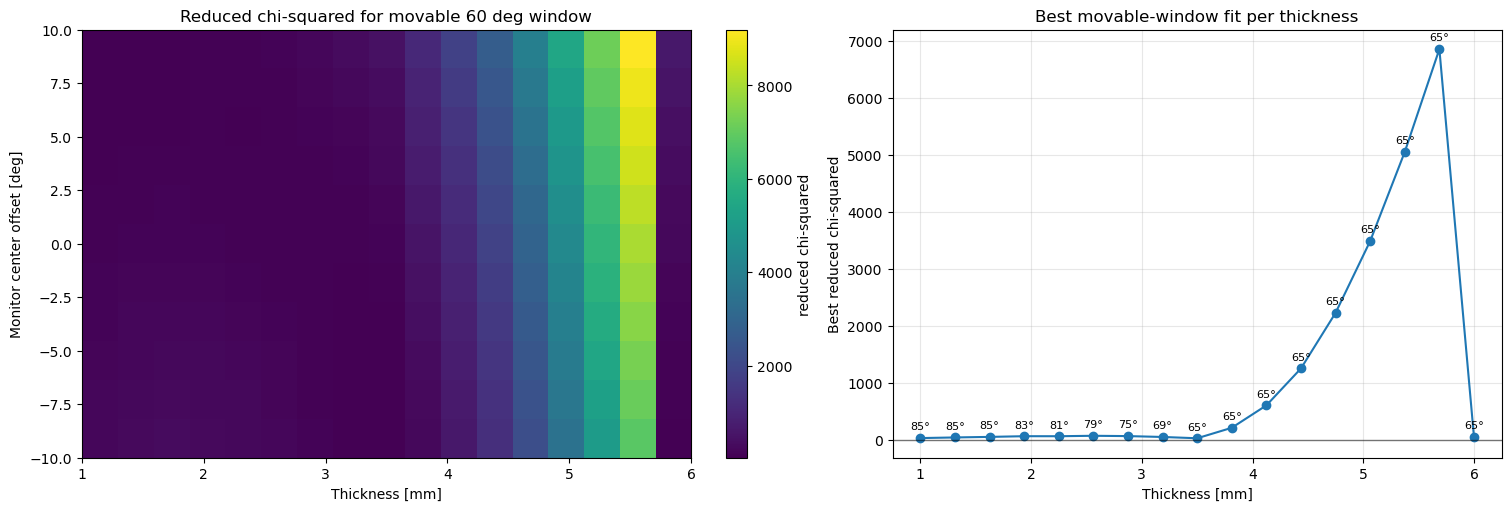

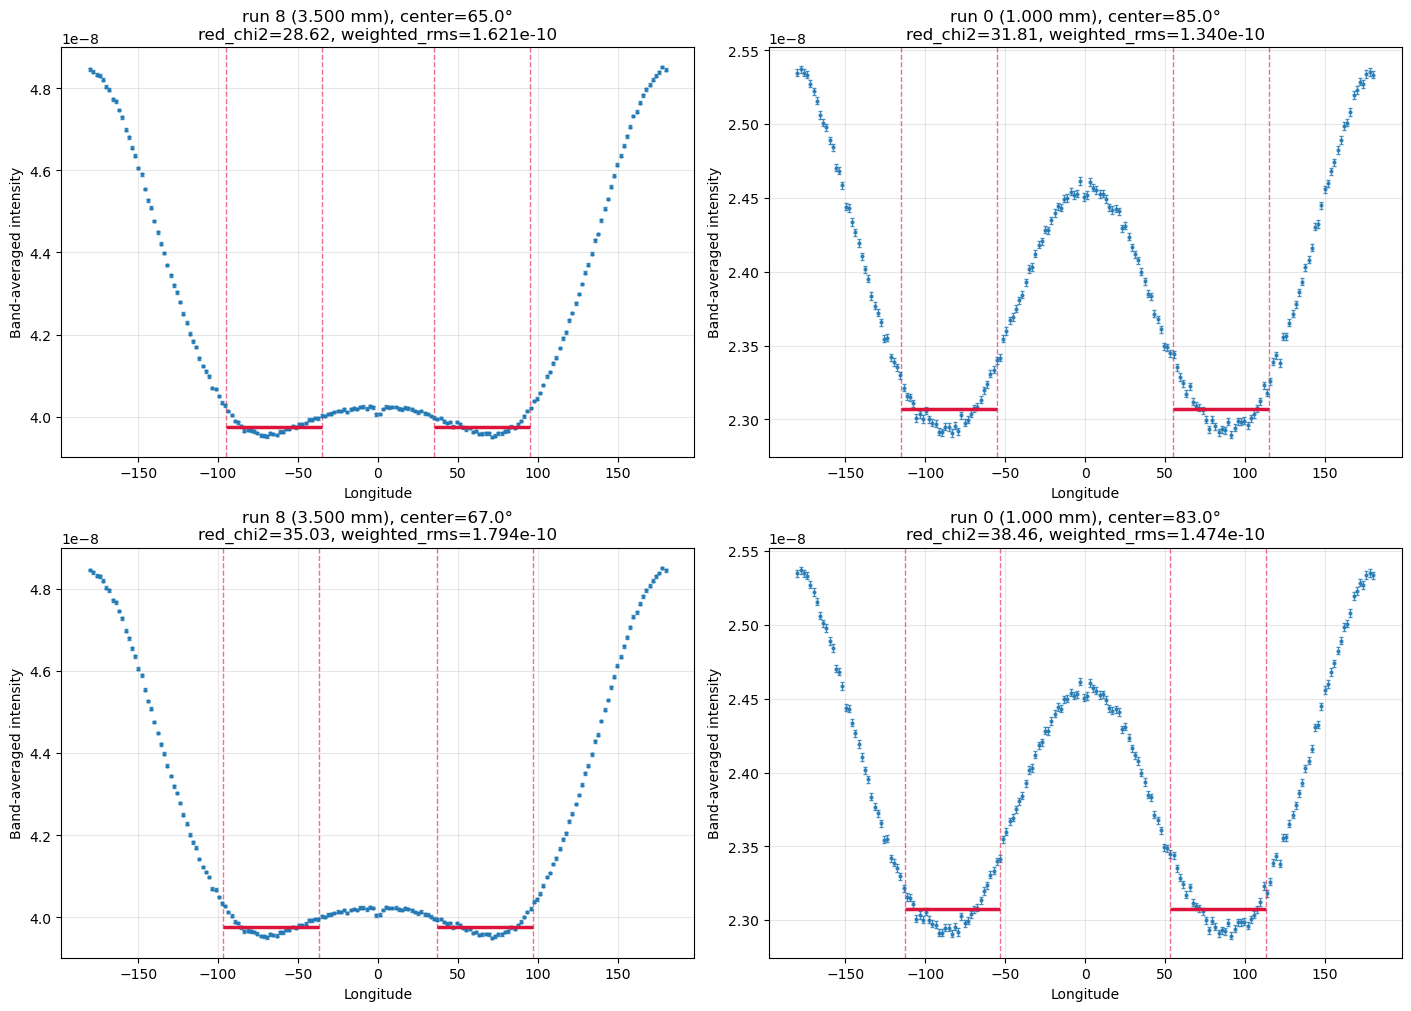

In [128]:
# Movable 60 degree detector-window flatness test.
# For each thickness, scan a few detector-center offsets and fit a constant
# in the two symmetric detector windows.
scan_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1to6_r15mmh4cm_bathed_1e9')
run_indices = list(range(17))
thicknesses_mm = np.linspace(1, 6, len(run_indices))

detector_window_width_deg = 60.0
ominal_detector_center_deg = 75.0
center_offsets_deg = np.arange(-10.0, 10.1, 2.0)
low_outlier_fraction = 0.8
equator_band_halfwidth_local = 50.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0


def get_equator_cut(run_path):
    sphere_mon = ms.load_data(str(run_path))[2]
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local) &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )
    Hmc_corrected = np.where(~beam_center_mask, Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(~beam_center_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth_local
    equator_band = Hmc_corrected[equator_band_mask, :]
    equator_band_err = Hmc_err_corrected[equator_band_mask, :]

    # Remove zero bins from McStas angular filtering before averaging.
    nonzero_band = equator_band > 0
    equator_band = np.where(nonzero_band, equator_band, np.nan)
    equator_band_err = np.where(nonzero_band, equator_band_err, np.nan)

    equator_cut = np.nanmean(equator_band, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
        np.nan,
    )

    valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
    low_outlier_threshold = low_outlier_fraction * np.nanmedian(equator_cut[valid_cols])
    valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)

    return lon, equator_cut, equator_cut_err, valid_cols


def constant_fit_score(lon, y, sigma, valid_cols, center_deg):
    half_width = detector_window_width_deg / 2.0
    pos_min = center_deg - half_width
    pos_max = center_deg + half_width
    neg_min = -pos_max
    neg_max = -pos_min

    fit_mask = valid_cols & (((lon >= pos_min) & (lon <= pos_max)) | ((lon >= neg_min) & (lon <= neg_max)))
    x_fit = lon[fit_mask]
    y_fit = y[fit_mask]
    sigma_fit = sigma[fit_mask]

    finite = np.isfinite(x_fit) & np.isfinite(y_fit) & np.isfinite(sigma_fit) & (sigma_fit > 0)
    x_fit = x_fit[finite]
    y_fit = y_fit[finite]
    sigma_fit = sigma_fit[finite]

    if len(x_fit) < 2:
        return None

    weights = 1.0 / sigma_fit**2
    const = np.sum(weights * y_fit) / np.sum(weights)
    const_err = np.sqrt(1.0 / np.sum(weights))
    residuals = y_fit - const
    chi2 = np.sum((residuals / sigma_fit) ** 2)
    ndof = len(y_fit) - 1
    red_chi2 = chi2 / ndof if ndof > 0 else np.nan
    weighted_rms = np.sqrt(np.sum(weights * residuals**2) / np.sum(weights))

    return {
        'center_deg': center_deg,
        'pos_min': pos_min,
        'pos_max': pos_max,
        'neg_min': neg_min,
        'neg_max': neg_max,
        'const': const,
        'const_err': const_err,
        'red_chi2': red_chi2,
        'weighted_rms': weighted_rms,
        'n_points': len(x_fit),
    }

all_results = []
best_by_thickness = []

for run_idx, thickness_mm in zip(run_indices, thicknesses_mm):
    lon, equator_cut, equator_cut_err, valid_cols = get_equator_cut(scan_root / str(run_idx))

    run_scores = []
    for offset_deg in center_offsets_deg:
        center_deg = nominal_detector_center_deg + offset_deg
        score = constant_fit_score(lon, equator_cut, equator_cut_err, valid_cols, center_deg)
        if score is None:
            continue
        score.update({
            'run_idx': run_idx,
            'thickness_mm': thickness_mm,
            'offset_deg': offset_deg,
            'lon_plot': lon[valid_cols],
            'equator_cut_plot': equator_cut[valid_cols],
            'equator_cut_err_plot': equator_cut_err[valid_cols],
        })
        run_scores.append(score)
        all_results.append(score)

    best_by_thickness.append(min(run_scores, key=lambda r: r['red_chi2']))

best_overall = min(all_results, key=lambda r: r['red_chi2'])
print(
    f"Best movable-window result: run {best_overall['run_idx']} "
    f"({best_overall['thickness_mm']:.3f} mm), center={best_overall['center_deg']:.1f} deg "
    f"(offset {best_overall['offset_deg']:+.1f} deg), red_chi2={best_overall['red_chi2']:.3f}, "
    f"weighted_rms={best_overall['weighted_rms']:.3e}, n={best_overall['n_points']}"
)

print("\nBest monitor center for each thickness:")
for r in best_by_thickness:
    print(
        f"thickness={r['thickness_mm']:.3f} mm: center={r['center_deg']:.1f} deg "
        f"(offset {r['offset_deg']:+.1f}), red_chi2={r['red_chi2']:.3f}"
    )

# Percentage difference within detector window for best overall
r = best_overall
lon_plot = r['lon_plot']
vals = r['equator_cut_plot']
pos_mask = (lon_plot >= r['pos_min']) & (lon_plot <= r['pos_max'])
neg_mask = (lon_plot >= r['neg_min']) & (lon_plot <= r['neg_max'])
window_mask = pos_mask | neg_mask
vals_in_window = np.array(vals)[window_mask]
valid_mask = np.isfinite(vals_in_window) & (vals_in_window > 0)
if np.any(valid_mask):
    mx = np.nanmax(vals_in_window[valid_mask])
    mn = np.nanmin(vals_in_window[valid_mask])
    pct_diff = 100.0 * (mx - mn) / mx if mx > 0 else 0.0
    print(f"Pct diff within detector window (best overall): {pct_diff:.3f}% (max={mx:.3e}, min={mn:.3e})")
else:
    print("No valid positive intensities in detector window for best overall.")

# Heatmap: red_chi2 as function of detector-center offset and thickness.
heatmap = np.full((len(center_offsets_deg), len(thicknesses_mm)), np.nan)
for r in all_results:
    i = np.where(center_offsets_deg == r['offset_deg'])[0][0]
    j = np.where(np.isclose(thicknesses_mm, r['thickness_mm']))[0][0]
    heatmap[i, j] = r['red_chi2']

fig, axs = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
im = axs[0].imshow(
    heatmap,
    origin='lower',
    aspect='auto',
    extent=[thicknesses_mm[0], thicknesses_mm[-1], center_offsets_deg[0], center_offsets_deg[-1]],
    cmap='viridis',
)
axs[0].set_xlabel('Thickness [mm]')
axs[0].set_ylabel('Monitor center offset [deg]')
axs[0].set_title('Reduced chi-squared for movable 60 deg window')
fig.colorbar(im, ax=axs[0], label='reduced chi-squared')

axs[1].plot(
    [r['thickness_mm'] for r in best_by_thickness],
    [r['red_chi2'] for r in best_by_thickness],
    'o-',
)
for r in best_by_thickness:
    axs[1].annotate(f"{r['center_deg']:.0f}°", (r['thickness_mm'], r['red_chi2']), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
axs[1].axhline(1.0, color='k', lw=1, alpha=0.5)
axs[1].set_xlabel('Thickness [mm]')
axs[1].set_ylabel('Best reduced chi-squared')
axs[1].set_title('Best movable-window fit per thickness')
axs[1].grid(True, alpha=0.3)
plt.show()

# Inspect best four movable-window candidates.
best_four = sorted(all_results, key=lambda r: r['red_chi2'])[:4]
fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axs = axs.ravel()

for ax, r in zip(axs, best_four):
    ax.errorbar(
        r['lon_plot'],
        r['equator_cut_plot'],
        yerr=r['equator_cut_err_plot'],
        fmt='o',
        ms=2,
        elinewidth=0.8,
        capsize=1.5,
        alpha=0.8,
    )
    ax.hlines(r['const'], r['pos_min'], r['pos_max'], color='crimson', lw=2.5, zorder=5)
    ax.hlines(r['const'], r['neg_min'], r['neg_max'], color='crimson', lw=2.5, zorder=5)
    for xline in [r['pos_min'], r['pos_max'], r['neg_min'], r['neg_max']]:
        ax.axvline(xline, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Band-averaged intensity')
    ax.set_title(
        f"run {r['run_idx']} ({r['thickness_mm']:.3f} mm), center={r['center_deg']:.1f}°\n"
        f"red_chi2={r['red_chi2']:.2f}, weighted_rms={r['weighted_rms']:.3e}"
    )
    ax.grid(True, alpha=0.3)

plt.show()


Best movable-window result by S=sigma/mean: run 8 (3.500 mm), center=65.0 deg (offset -10.0 deg), S=0.0041, sigma_window=1.636e-10, mean_window=3.975e-08, n=60

Best monitor center for each thickness:
thickness=1.000 mm: center=85.0 deg (offset +10.0), S=0.0059, sigma=1.355e-10, mean=2.307e-08
thickness=1.312 mm: center=85.0 deg (offset +10.0), S=0.0063, sigma=1.683e-10, mean=2.670e-08
thickness=1.625 mm: center=85.0 deg (offset +10.0), S=0.0066, sigma=1.961e-10, mean=2.977e-08
thickness=1.938 mm: center=83.0 deg (offset +8.0), S=0.0070, sigma=2.259e-10, mean=3.234e-08
thickness=2.250 mm: center=81.0 deg (offset +6.0), S=0.0067, sigma=2.317e-10, mean=3.450e-08
thickness=2.562 mm: center=79.0 deg (offset +4.0), S=0.0069, sigma=2.505e-10, mean=3.628e-08
thickness=2.875 mm: center=75.0 deg (offset +0.0), S=0.0065, sigma=2.448e-10, mean=3.774e-08
thickness=3.188 mm: center=69.0 deg (offset -6.0), S=0.0056, sigma=2.175e-10, mean=3.889e-08
thickness=3.500 mm: center=65.0 deg (offset -10.0), 

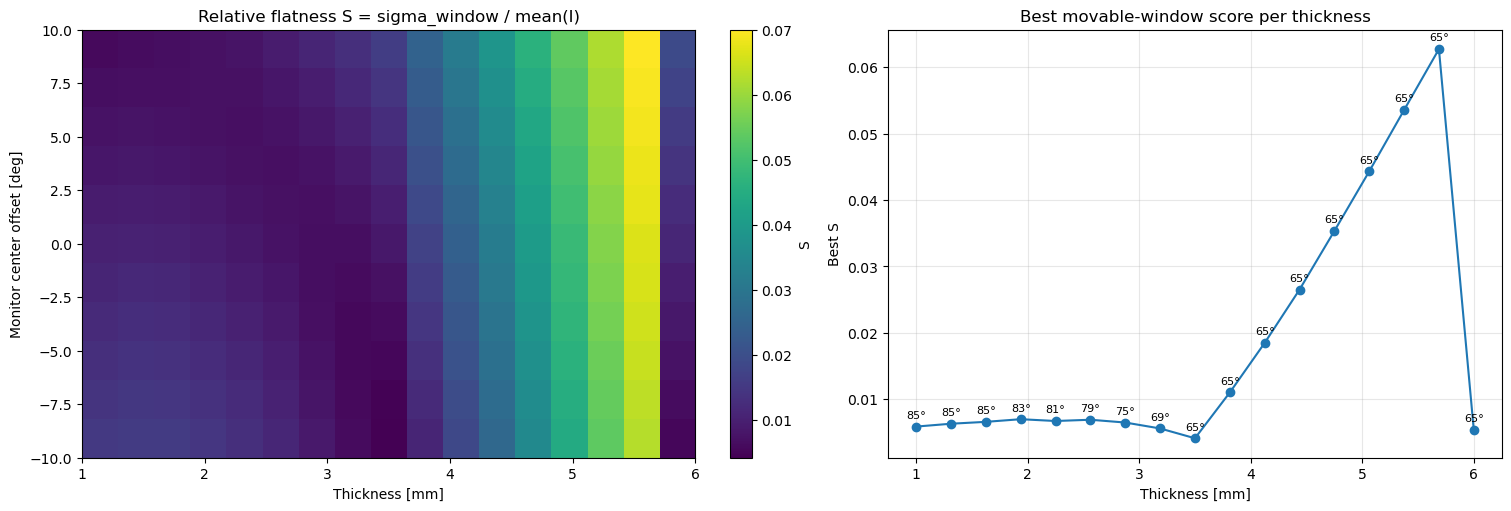

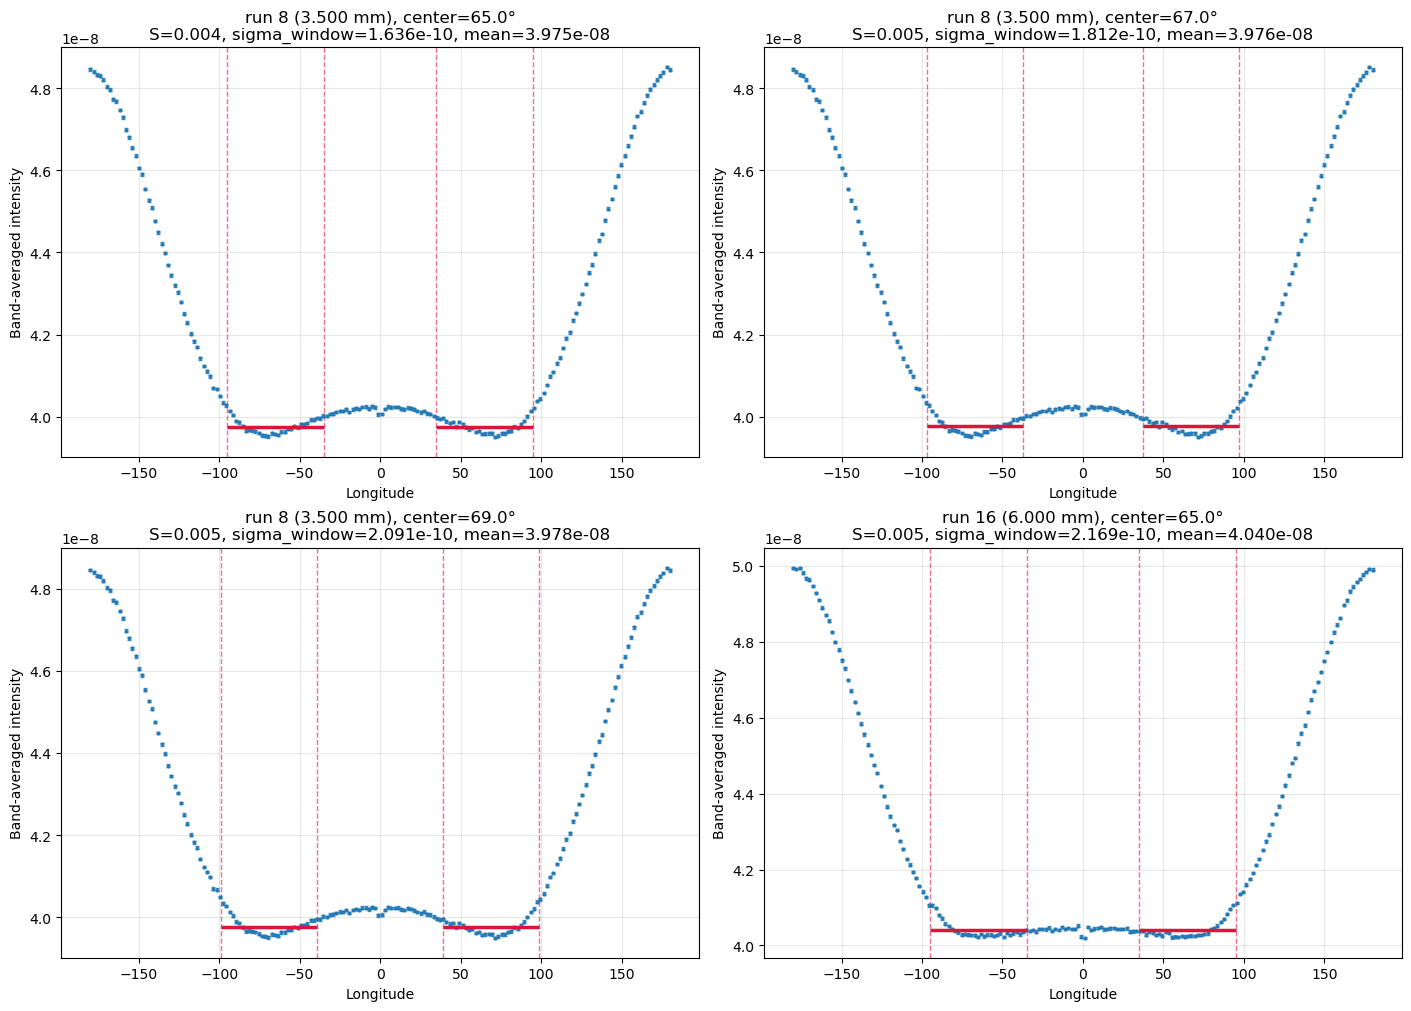

In [127]:
# Movable 60 degree detector-window optimization using a relative flatness metric.
# Scores each candidate with S = sigma_window / mean(I) in the detector window.
scan_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1to6_r15mmh4cm_bathed_1e9')
run_indices = list(range(17))
thicknesses_mm = np.linspace(1.0, 6.0, len(run_indices))

detector_window_width_deg = 60.0
nominal_detector_center_deg = 75.0
center_offsets_deg = np.arange(-10.0, 10.1, 2.0)
low_outlier_fraction = 0.8
equator_band_halfwidth_local = 50.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0


def get_equator_cut_sigma(run_path):
    sphere_mon = ms.load_data(str(run_path))[2]
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local) &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )
    Hmc_corrected = np.where(~beam_center_mask, Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(~beam_center_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth_local
    equator_band = Hmc_corrected[equator_band_mask, :]
    equator_band_err = Hmc_err_corrected[equator_band_mask, :]

    # Remove zero bins from the McStas angular filter before averaging.
    nonzero_band = equator_band > 0
    equator_band = np.where(nonzero_band, equator_band, np.nan)
    equator_band_err = np.where(nonzero_band, equator_band_err, np.nan)

    equator_cut = np.nanmean(equator_band, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
        np.nan,
    )

    valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
    low_outlier_threshold = low_outlier_fraction * np.nanmedian(equator_cut[valid_cols])
    valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)

    return lon, equator_cut, equator_cut_err, valid_cols


def relative_flatness_score(lon, y, valid_cols, center_deg):
    half_width = detector_window_width_deg / 2.0
    pos_min = center_deg - half_width
    pos_max = center_deg + half_width
    neg_min = -pos_max
    neg_max = -pos_min

    fit_mask = valid_cols & (((lon >= pos_min) & (lon <= pos_max)) | ((lon >= neg_min) & (lon <= neg_max)))
    x_fit = lon[fit_mask]
    y_fit = np.asarray(y)[fit_mask]
    y_fit = y_fit[np.isfinite(y_fit) & (y_fit > 0)]

    if y_fit.size < 2:
        return None

    mean_window = np.mean(y_fit)
    sigma_window = np.std(y_fit, ddof=1)
    s_value = sigma_window / mean_window if mean_window > 0 else np.nan

    return {
        'center_deg': center_deg,
        'pos_min': pos_min,
        'pos_max': pos_max,
        'neg_min': neg_min,
        'neg_max': neg_max,
        'mean_window': mean_window,
        'sigma_window': sigma_window,
        'S': s_value,
        'n_points': len(y_fit),
    }

all_results_sigma = []
best_by_thickness_sigma = []

for run_idx, thickness_mm in zip(run_indices, thicknesses_mm):
    lon, equator_cut, equator_cut_err, valid_cols = get_equator_cut_sigma(scan_root / str(run_idx))

    run_scores = []
    for offset_deg in center_offsets_deg:
        center_deg = nominal_detector_center_deg + offset_deg
        score = relative_flatness_score(lon, equator_cut, valid_cols, center_deg)
        if score is None:
            continue
        score.update({
            'run_idx': run_idx,
            'thickness_mm': thickness_mm,
            'offset_deg': offset_deg,
            'lon_plot': lon[valid_cols],
            'equator_cut_plot': equator_cut[valid_cols],
            'equator_cut_err_plot': equator_cut_err[valid_cols],
        })
        run_scores.append(score)
        all_results_sigma.append(score)

    best_by_thickness_sigma.append(min(run_scores, key=lambda r: r['S']))

best_overall_sigma = min(all_results_sigma, key=lambda r: r['S'])
print(
    f"Best movable-window result by S=sigma/mean: run {best_overall_sigma['run_idx']} "
    f"({best_overall_sigma['thickness_mm']:.3f} mm), center={best_overall_sigma['center_deg']:.1f} deg "
    f"(offset {best_overall_sigma['offset_deg']:+.1f} deg), S={best_overall_sigma['S']:.4f}, "
    f"sigma_window={best_overall_sigma['sigma_window']:.3e}, mean_window={best_overall_sigma['mean_window']:.3e}, "
    f"n={best_overall_sigma['n_points']}"
)

print("\nBest monitor center for each thickness:")
for r in best_by_thickness_sigma:
    print(
        f"thickness={r['thickness_mm']:.3f} mm: center={r['center_deg']:.1f} deg "
        f"(offset {r['offset_deg']:+.1f}), S={r['S']:.4f}, sigma={r['sigma_window']:.3e}, mean={r['mean_window']:.3e}"
    )

# Percentage spread within detector window for best overall.
r = best_overall_sigma
lon_plot = r['lon_plot']
vals = r['equator_cut_plot']
pos_mask = (lon_plot >= r['pos_min']) & (lon_plot <= r['pos_max'])
neg_mask = (lon_plot >= r['neg_min']) & (lon_plot <= r['neg_max'])
window_mask = pos_mask | neg_mask
vals_in_window = np.array(vals)[window_mask]
valid_mask = np.isfinite(vals_in_window) & (vals_in_window > 0)
if np.any(valid_mask):
    mx = np.nanmax(vals_in_window[valid_mask])
    mn = np.nanmin(vals_in_window[valid_mask])
    pct_diff = 100.0 * (mx - mn) / mx if mx > 0 else 0.0
    print(f"Pct diff within detector window (best overall): {pct_diff:.3f}% (max={mx:.3e}, min={mn:.3e})")
else:
    print("No valid positive intensities in detector window for best overall.")

# Heatmap: S as function of detector-center offset and thickness.
heatmap = np.full((len(center_offsets_deg), len(thicknesses_mm)), np.nan)
for r in all_results_sigma:
    i = np.where(center_offsets_deg == r['offset_deg'])[0][0]
    j = np.where(np.isclose(thicknesses_mm, r['thickness_mm']))[0][0]
    heatmap[i, j] = r['S']

fig, axs = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
im = axs[0].imshow(
    heatmap,
    origin='lower',
    aspect='auto',
    extent=[thicknesses_mm[0], thicknesses_mm[-1], center_offsets_deg[0], center_offsets_deg[-1]],
    cmap='viridis',
)
axs[0].set_xlabel('Thickness [mm]')
axs[0].set_ylabel('Monitor center offset [deg]')
axs[0].set_title('Relative flatness S = sigma_window / mean(I)')
fig.colorbar(im, ax=axs[0], label='S')

axs[1].plot(
    [r['thickness_mm'] for r in best_by_thickness_sigma],
    [r['S'] for r in best_by_thickness_sigma],
    'o-',
)
for r in best_by_thickness_sigma:
    axs[1].annotate(f"{r['center_deg']:.0f}°", (r['thickness_mm'], r['S']), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
axs[1].set_xlabel('Thickness [mm]')
axs[1].set_ylabel('Best S')
axs[1].set_title('Best movable-window score per thickness')
axs[1].grid(True, alpha=0.3)
plt.show()

# Inspect best four movable-window candidates.
best_four = sorted(all_results_sigma, key=lambda r: r['S'])[:4]
fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axs = axs.ravel()

for ax, r in zip(axs, best_four):
    ax.errorbar(
        r['lon_plot'],
        r['equator_cut_plot'],
        yerr=r['equator_cut_err_plot'],
        fmt='o',
        ms=2,
        elinewidth=0.8,
        capsize=1.5,
        alpha=0.8,
    )
    window_const = np.nanmean(r['equator_cut_plot'][(r['lon_plot'] >= r['pos_min']) & (r['lon_plot'] <= r['pos_max']) | (r['lon_plot'] >= r['neg_min']) & (r['lon_plot'] <= r['neg_max'])])
    ax.hlines(window_const, r['pos_min'], r['pos_max'], color='crimson', lw=2.5, zorder=5)
    ax.hlines(window_const, r['neg_min'], r['neg_max'], color='crimson', lw=2.5, zorder=5)
    for xline in [r['pos_min'], r['pos_max'], r['neg_min'], r['neg_max']]:
        ax.axvline(xline, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Band-averaged intensity')
    ax.set_title(
        f"run {r['run_idx']} ({r['thickness_mm']:.3f} mm), center={r['center_deg']:.1f}°\n"
        f"S={r['S']:.3f}, sigma_window={r['sigma_window']:.3e}, mean={r['mean_window']:.3e}"
    )
    ax.grid(True, alpha=0.3)

plt.show()


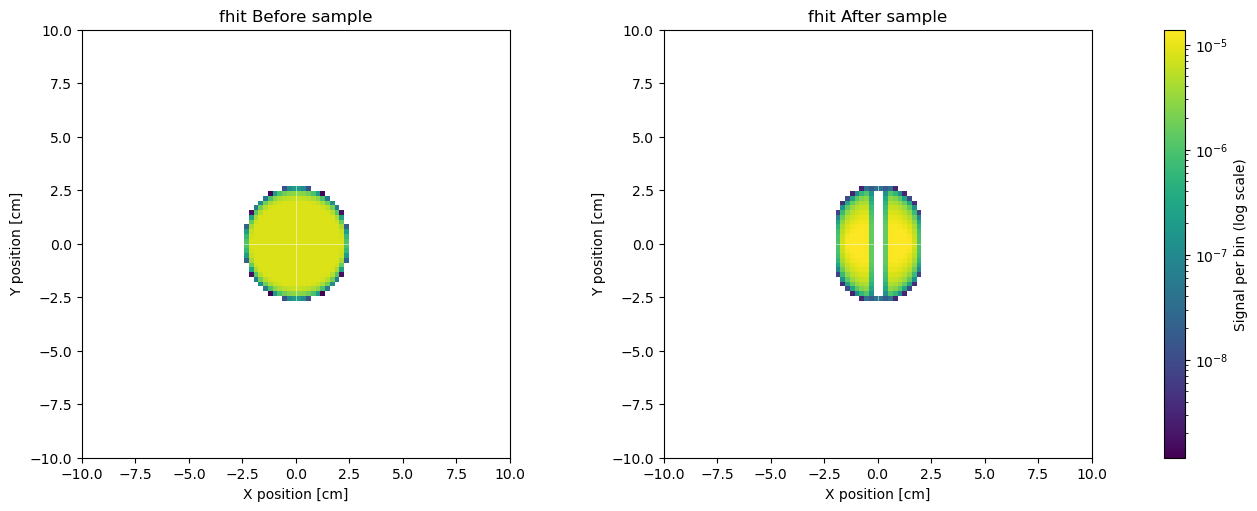

Before total intensity: 2.696692e-03
After total intensity:  1.847900e-03
After / before:         0.685247
Beam footprint fraction: 0.314753
Beam area at sample:     21.135802 cm^2


In [129]:
from matplotlib.colors import LogNorm

fhit_dir = Path('geometry_optimization/cylinder_instrument/fhit_r1cmh6cm')
if not fhit_dir.exists():
    fhit_dir = Path('cylinder_instrument/fhit_r5mmh5cm')

def load_mccode_2d(path):
    path = Path(path)
    meta = {}
    nrows = None
    data_rows = []
    in_data = False
    with path.open() as f:
        for line in f:
            if line.startswith('# type: array_2d'):
                dims = line.split('array_2d(', 1)[1].split(')', 1)[0]
                nrows = int(dims.split(',')[1].strip())
            elif line.startswith('# xylimits:'):
                meta['extent'] = [float(v) for v in line.split(':', 1)[1].split()]
            elif line.startswith('# component:'):
                meta['component'] = line.split(':', 1)[1].strip()
            elif line.startswith('# Data'):
                in_data = True
            elif in_data and line.startswith('#'):
                break
            elif in_data and line.strip():
                data_rows.append([float(v) for v in line.split()])
                if nrows is not None and len(data_rows) == nrows:
                    break

    if nrows is None:
        raise ValueError(f'Could not find array_2d dimensions in {path}')
    if len(data_rows) != nrows:
        raise ValueError(f'Expected {nrows} rows from {path}, got {len(data_rows)}')

    data = np.array(data_rows)
    return data, meta

before, before_meta = load_mccode_2d(fhit_dir / 'before.dat')
after, after_meta = load_mccode_2d(fhit_dir / 'after.dat')
extent = before_meta.get('extent', [-10, 10, -10, 10])

positive_values = np.concatenate([before[before > 0], after[after > 0]])
norm = LogNorm(vmin=positive_values.min(), vmax=positive_values.max())

fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, image, title in [
    (axs[0], before, 'Before sample'),
    (axs[1], after, 'After sample'),
]:
    im = ax.imshow(
        np.ma.masked_less_equal(image, 0),
        extent=extent,
        origin='lower',
        aspect='equal',
        cmap='viridis',
        norm=norm,
    )
    ax.set_title(f'fhit {title}')
    ax.set_xlabel('X position [cm]')
    ax.set_ylabel('Y position [cm]')
    ax.axhline(0, color='white', lw=0.7, alpha=0.5)
    ax.axvline(0, color='white', lw=0.7, alpha=0.5)

fig.colorbar(im, ax=axs, label='Signal per bin (log scale)')
plt.show()

bin_width_x = (extent[1] - extent[0]) / before.shape[1]
bin_width_y = (extent[3] - extent[2]) / before.shape[0]
bin_area = abs(bin_width_x * bin_width_y)
beam_area_cm2 = np.count_nonzero(before > 0) * bin_area

print(f"Before total intensity: {before.sum():.6e}")
print(f"After total intensity:  {after.sum():.6e}")
print(f"After / before:         {after.sum() / before.sum():.6f}")
print(f"Beam footprint fraction: {1 - (after.sum() / before.sum()):.6f}")
print(f"Beam area at sample:     {beam_area_cm2:.6f} cm^2")


Intensity reference (1cm radius median fitted constant): 1.281e-08
Best coarse 3D geometry (intensity-penalized): radius=10.00 mm, height=60.00 mm, wall=1.75 mm, detector offset=-2.0 deg, red_chi2=2.314, fitted_intensity=4.258e-08, penalty=0.443, penalized_score=1.026

Top coarse candidates (sorted by penalized score):
1. r=10.00 mm, h=60.00 mm, t=1.75 mm, offset=-2.0 deg, red_chi2=2.314, fitted_intensity=4.258e-08, penalty=0.443, penalized=1.026
2. r=5.00 mm, h=30.00 mm, t=1.00 mm, offset=-2.0 deg, red_chi2=0.867, fitted_intensity=2.317e-09, penalty=1.332, penalized=1.154
3. r=10.00 mm, h=60.00 mm, t=1.50 mm, offset=+1.0 deg, red_chi2=2.565, fitted_intensity=3.945e-08, penalty=0.483, penalized=1.238
4. r=15.00 mm, h=60.00 mm, t=2.25 mm, offset=-2.0 deg, red_chi2=11.917, fitted_intensity=9.525e-08, penalty=0.105, penalized=1.252
5. r=20.00 mm, h=60.00 mm, t=2.75 mm, offset=-2.0 deg, red_chi2=63.318, fitted_intensity=1.558e-07, penalty=0.020, penalized=1.271
6. r=5.00 mm, h=60.00 mm, t=

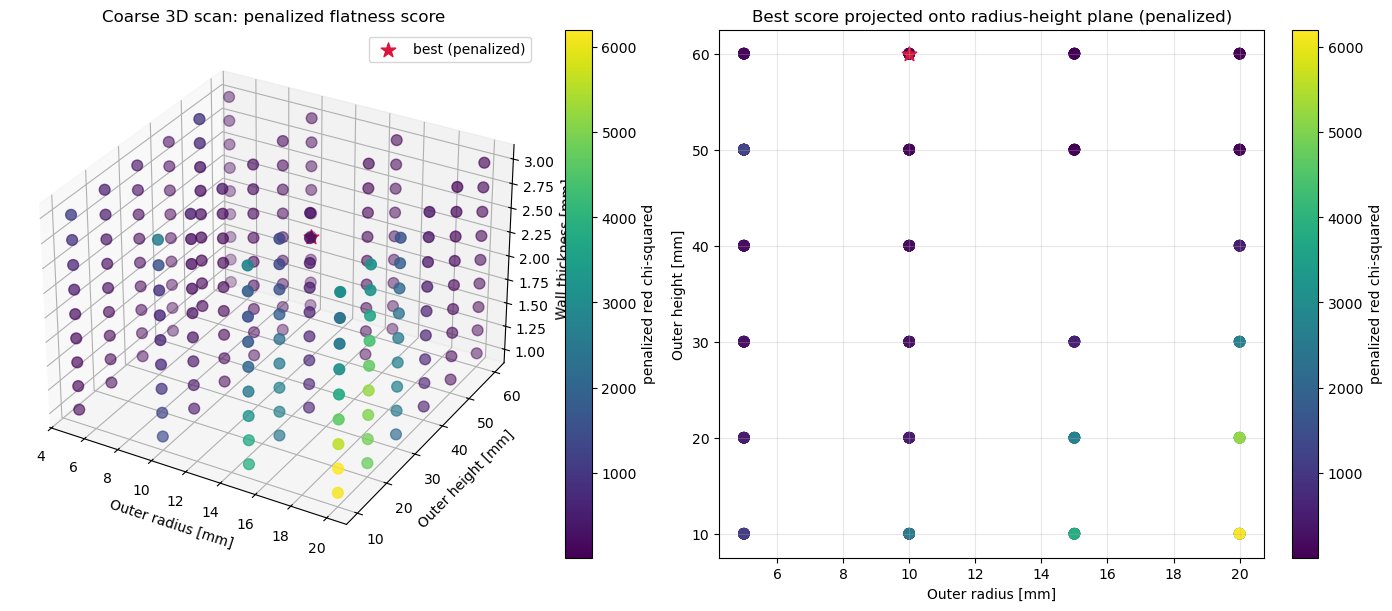

In [130]:
# Coarse 3D scan over cylinder outer radius, outer height, and wall thickness.
# The cell auto-discovers the existing `1to3_*` geometry folders, then scans the
# 9 thickness runs inside each folder while still allowing the detector center to
# move by a couple of degrees around the nominal position.
# Includes intensity-dependent penalty to avoid bias toward low-signal geometries.
import re

coarse_scan_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument')
nominal_detector_center_deg = 75.0

outer_radius_grid_mm = np.array([5.0, 10.0, 15.0, 20.0])
outer_height_grid_mm = np.arange(10.0, 61.0, 10.0)
wall_thickness_grid_mm = np.linspace(1.0, 3.0, 9)
detector_center_offsets_deg = np.arange(-2.0, 2.1, 1.0)

# Intensity penalty parameters
intensity_penalty_lambda = 0.35  # Exponential decay constant; higher = stronger penalty for low intensity
intensity_penalty_enabled = True


def parse_geometry_folder_name(folder_name):
    match = re.match(r'^1to3_r(?P<radius>[^h]+)h(?P<height>[^_]+)_bathed_(?P<tag>.+)$', folder_name)
    if match is None:
        return None

    radius_token = match.group('radius')
    height_token = match.group('height')

    def to_mm(token):
        if token.endswith('mm'):
            return float(token[:-2])
        if token.endswith('cm'):
            return float(token[:-2]) * 10.0
        raise ValueError(f'Unsupported unit in {token}')

    return {
        'outer_radius_mm': to_mm(radius_token),
        'outer_height_mm': to_mm(height_token),
    }


def load_scattered_monitor(run_dir):
    loaded = ms.load_data(str(run_dir))
    if not loaded:
        raise ValueError(f'No McStas data loaded from {run_dir}')
    if len(loaded) >= 3:
        return loaded[2]
    return loaded[-1]


def get_equator_cut_from_run(run_dir):
    sphere_mon = load_scattered_monitor(run_dir)
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local) &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )
    Hmc_corrected = np.where(~beam_center_mask, Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(~beam_center_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth_local
    equator_band = Hmc_corrected[equator_band_mask, :]
    equator_band_err = Hmc_err_corrected[equator_band_mask, :]

    nonzero_band = equator_band > 0
    equator_band = np.where(nonzero_band, equator_band, np.nan)
    equator_band_err = np.where(nonzero_band, equator_band_err, np.nan)

    equator_cut = np.nanmean(equator_band, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
        np.nan,
    )

    valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
    low_outlier_threshold = low_outlier_fraction * np.nanmedian(equator_cut[valid_cols])
    valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)

    return lon, equator_cut, equator_cut_err, valid_cols


def analyze_geometry_run(run_dir):
    lon, equator_cut, equator_cut_err, valid_cols = get_equator_cut_from_run(run_dir)

    best_score = None
    for offset_deg in detector_center_offsets_deg:
        center_deg = nominal_detector_center_deg + offset_deg
        score = constant_fit_score(lon, equator_cut, equator_cut_err, valid_cols, center_deg)
        if score is None:
            continue
        score.update({
            'offset_deg': offset_deg,
            'lon_plot': lon[valid_cols],
            'equator_cut_plot': equator_cut[valid_cols],
            'equator_cut_err_plot': equator_cut_err[valid_cols],
        })
        if best_score is None or score['red_chi2'] < best_score['red_chi2']:
            best_score = score

    return best_score


geometry_dirs = []
for path in sorted(coarse_scan_root.iterdir()):
    if not path.is_dir() or not path.name.startswith('1to3_r') or '_bathed_' not in path.name:
        continue
    parsed = parse_geometry_folder_name(path.name)
    if parsed is None:
        continue
    parsed['path'] = path
    geometry_dirs.append(parsed)

coarse_scan_results = []

for geometry in geometry_dirs:
    geometry_path = geometry['path']
    for run_idx, wall_thickness_mm in enumerate(wall_thickness_grid_mm):
        run_dir = geometry_path / str(run_idx)
        if not run_dir.exists():
            continue

        best_score = analyze_geometry_run(run_dir)
        if best_score is None:
            continue

        best_score.update({
            'outer_radius_mm': geometry['outer_radius_mm'],
            'outer_height_mm': geometry['outer_height_mm'],
            'wall_thickness_mm': wall_thickness_mm,
            'geometry_dir': str(geometry_path),
            'run_idx': run_idx,
            'run_dir': str(run_dir),
        })
        coarse_scan_results.append(best_score)

# Calculate intensity reference (median fitted constant of 1cm samples for normalization)
results_1cm = [r for r in coarse_scan_results if r['outer_radius_mm'] == 10.0]
if results_1cm:
    intensity_reference = np.median([r['const'] for r in results_1cm])
else:
    # Fallback: use median of all results
    intensity_reference = np.median([r['const'] for r in coarse_scan_results])

print(f"Intensity reference (1cm radius median fitted constant): {intensity_reference:.3e}")

# Apply intensity penalty to all results
if intensity_penalty_enabled:
    for r in coarse_scan_results:
        # Exponential penalty: exp(-lambda * (I / I_ref - 1))
        # When I = I_ref: penalty = 1 (no penalty)
        # When I < I_ref: penalty > 1 (worse score)
        # When I > I_ref: penalty < 1 (better score)
        intensity_factor = np.exp(-intensity_penalty_lambda * (r['const'] / intensity_reference - 1.0))
        r['intensity_penalty'] = intensity_factor
        r['penalized_red_chi2'] = r['red_chi2'] * intensity_factor
    coarse_scan_results = sorted(coarse_scan_results, key=lambda r: r['penalized_red_chi2'])
else:
    for r in coarse_scan_results:
        r['penalized_red_chi2'] = r['red_chi2']
    coarse_scan_results = sorted(coarse_scan_results, key=lambda r: r['red_chi2'])


if coarse_scan_results:
    best_coarse = coarse_scan_results[0]

    print(
        f"Best coarse 3D geometry (intensity-penalized): radius={best_coarse['outer_radius_mm']:.2f} mm, "
        f"height={best_coarse['outer_height_mm']:.2f} mm, "
        f"wall={best_coarse['wall_thickness_mm']:.2f} mm, "
        f"detector offset={best_coarse['offset_deg']:+.1f} deg, "
        f"red_chi2={best_coarse['red_chi2']:.3f}, fitted_intensity={best_coarse['const']:.3e}, "
        f"penalty={best_coarse['intensity_penalty']:.3f}, penalized_score={best_coarse['penalized_red_chi2']:.3f}"
    )

    print("\nTop coarse candidates (sorted by penalized score):")
    for i, candidate in enumerate(coarse_scan_results[:10]):
        print(
            f"{i+1}. r={candidate['outer_radius_mm']:.2f} mm, "
            f"h={candidate['outer_height_mm']:.2f} mm, "
            f"t={candidate['wall_thickness_mm']:.2f} mm, "
            f"offset={candidate['offset_deg']:+.1f} deg, "
            f"red_chi2={candidate['red_chi2']:.3f}, fitted_intensity={candidate['const']:.3e}, "
            f"penalty={candidate['intensity_penalty']:.3f}, penalized={candidate['penalized_red_chi2']:.3f}"
        )

    fig = plt.figure(figsize=(14, 6), constrained_layout=True)
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')
    sc = ax3d.scatter(
        [r['outer_radius_mm'] for r in coarse_scan_results],
        [r['outer_height_mm'] for r in coarse_scan_results],
        [r['wall_thickness_mm'] for r in coarse_scan_results],
        c=[r['penalized_red_chi2'] for r in coarse_scan_results],
        cmap='viridis',
        s=60,
    )
    ax3d.scatter(
        best_coarse['outer_radius_mm'],
        best_coarse['outer_height_mm'],
        best_coarse['wall_thickness_mm'],
        color='crimson',
        s=120,
        marker='*',
        label='best (penalized)',
    )
    ax3d.set_xlabel('Outer radius [mm]')
    ax3d.set_ylabel('Outer height [mm]')
    ax3d.set_zlabel('Wall thickness [mm]')
    ax3d.set_title('Coarse 3D scan: penalized flatness score')
    ax3d.legend()
    fig.colorbar(sc, ax=ax3d, label='penalized red chi-squared')

    ax2d = fig.add_subplot(1, 2, 2)
    radius_vs_height = ax2d.scatter(
        [r['outer_radius_mm'] for r in coarse_scan_results],
        [r['outer_height_mm'] for r in coarse_scan_results],
        c=[r['penalized_red_chi2'] for r in coarse_scan_results],
        cmap='viridis',
        s=70,
        edgecolor='none',
    )
    ax2d.scatter(
        best_coarse['outer_radius_mm'],
        best_coarse['outer_height_mm'],
        color='crimson',
        s=120,
        marker='*',
    )
    ax2d.set_xlabel('Outer radius [mm]')
    ax2d.set_ylabel('Outer height [mm]')
    ax2d.set_title('Best score projected onto radius-height plane (penalized)')
    ax2d.grid(True, alpha=0.3)
    fig.colorbar(radius_vs_height, ax=ax2d, label='penalized red chi-squared')

    plt.show()
else:
    print('No coarse 3D scan results found yet. Populate the existing 1to3_* geometry folders and rerun this cell.')


Best 3D geometry by S=sigma/mean: radius=5.00 mm, height=50.00 mm, wall=1.00 mm, offset=-1.0 deg, S=0.0006, sigma_window=5.260e-12, mean_window=8.113e-09, n=60

Top 10 3D candidates by S:
1. r=5.00 mm, h=50.00 mm, t=1.00 mm, offset=-1.0 deg, S=0.0006, sigma_window=5.260e-12, mean_window=8.113e-09
2. r=10.00 mm, h=40.00 mm, t=2.00 mm, offset=-10.0 deg, S=0.0012, sigma_window=2.356e-11, mean_window=1.977e-08
3. r=5.00 mm, h=30.00 mm, t=1.00 mm, offset=-9.0 deg, S=0.0012, sigma_window=2.788e-12, mean_window=2.317e-09
4. r=5.00 mm, h=50.00 mm, t=1.25 mm, offset=+3.0 deg, S=0.0012, sigma_window=1.137e-11, mean_window=9.287e-09
5. r=10.00 mm, h=60.00 mm, t=1.75 mm, offset=-10.0 deg, S=0.0014, sigma_window=5.785e-11, mean_window=4.256e-08
6. r=5.00 mm, h=20.00 mm, t=1.00 mm, offset=-3.0 deg, S=0.0014, sigma_window=1.478e-12, mean_window=1.053e-09
7. r=10.00 mm, h=50.00 mm, t=1.75 mm, offset=-7.0 deg, S=0.0015, sigma_window=4.400e-11, mean_window=2.949e-08
8. r=5.00 mm, h=30.00 mm, t=1.25 mm, 

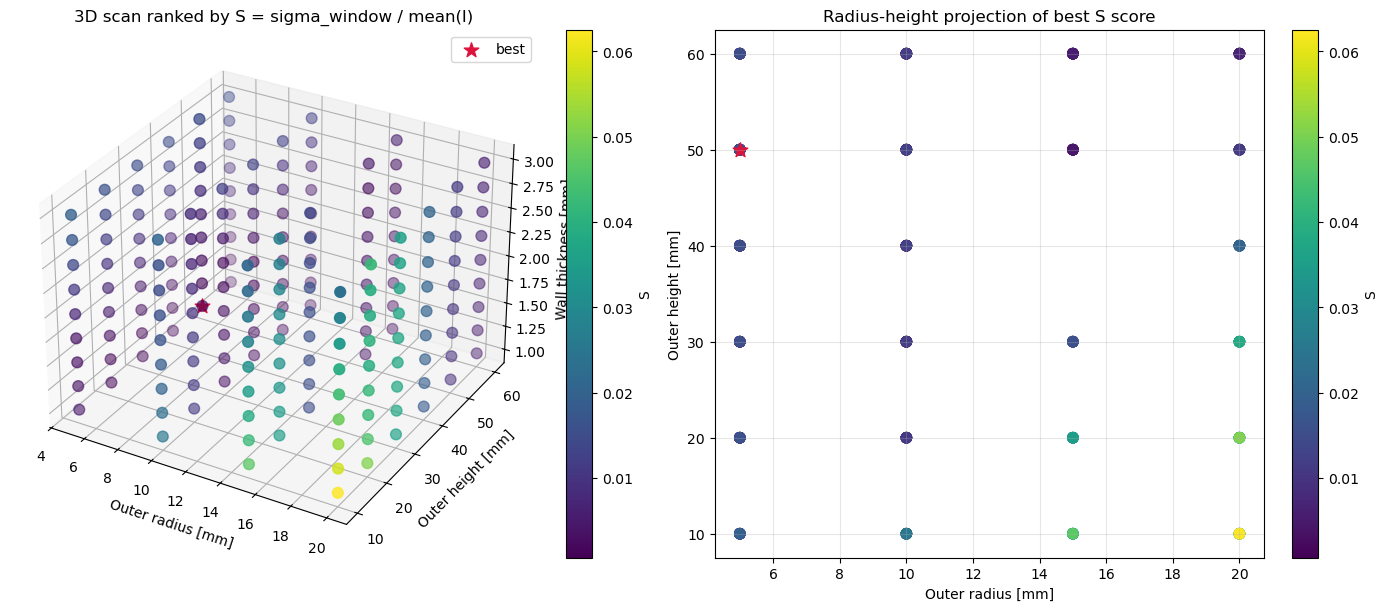

In [134]:
# Full 3D optimization scan using the relative flatness criterion S = sigma_window / mean(I).
# This scans outer radius, outer height, and wall thickness, then ranks each run by
# the relative spread in the detector window rather than by penalized chi-squared.
import re

scan_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument')
nominal_detector_center_deg = 75.0
center_offsets_deg = np.arange(-10.0, 10.1, 1.0)
low_outlier_fraction = 0.8
equator_band_halfwidth_local = 50.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0


def parse_3d_geometry(folder_name):
    match = re.match(r'^1to3_r(?P<radius>[^h]+)h(?P<height>[^_]+)_bathed_(?P<tag>.+)$', folder_name)
    if match is None:
        return None

    def to_mm(token):
        if token.endswith('mm'):
            return float(token[:-2])
        if token.endswith('cm'):
            return float(token[:-2]) * 10.0
        raise ValueError(f'Unsupported unit in {token}')

    return {
        'outer_radius_mm': to_mm(match.group('radius')),
        'outer_height_mm': to_mm(match.group('height')),
    }


def load_scattered_monitor_3d(run_dir):
    loaded = ms.load_data(str(run_dir))
    if not loaded:
        raise ValueError(f'No McStas data loaded from {run_dir}')
    return loaded[2] if len(loaded) >= 3 else loaded[-1]


def get_equator_cut_3d(run_dir):
    sphere_mon = load_scattered_monitor_3d(run_dir)
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local) &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )
    Hmc_corrected = np.where(~beam_center_mask, Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(~beam_center_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth_local
    equator_band = Hmc_corrected[equator_band_mask, :]
    equator_band_err = Hmc_err_corrected[equator_band_mask, :]

    nonzero_band = equator_band > 0
    equator_band = np.where(nonzero_band, equator_band, np.nan)
    equator_band_err = np.where(nonzero_band, equator_band_err, np.nan)

    equator_cut = np.nanmean(equator_band, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
        np.nan,
    )

    valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
    low_outlier_threshold = low_outlier_fraction * np.nanmedian(equator_cut[valid_cols])
    valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)

    return lon, equator_cut, equator_cut_err, valid_cols


def relative_flatness_score(lon, y, valid_cols, center_deg):
    half_width = 60.0 / 2.0
    pos_min = center_deg - half_width
    pos_max = center_deg + half_width
    neg_min = -pos_max
    neg_max = -pos_min

    fit_mask = valid_cols & (((lon >= pos_min) & (lon <= pos_max)) | ((lon >= neg_min) & (lon <= neg_max)))
    x_fit = lon[fit_mask]
    y_fit = np.asarray(y)[fit_mask]
    y_fit = y_fit[np.isfinite(y_fit) & (y_fit > 0)]

    if y_fit.size < 2:
        return None

    mean_window = np.mean(y_fit)
    sigma_window = np.std(y_fit, ddof=1)
    s_value = sigma_window / mean_window if mean_window > 0 else np.nan

    return {
        'center_deg': center_deg,
        'pos_min': pos_min,
        'pos_max': pos_max,
        'neg_min': neg_min,
        'neg_max': neg_max,
        'mean_window': mean_window,
        'sigma_window': sigma_window,
        'S': s_value,
        'n_points': len(y_fit),
    }

geometry_dirs = []
for path in sorted(scan_root.iterdir()):
    if not path.is_dir() or not path.name.startswith('1to3_r') or '_bathed_' not in path.name:
        continue
    parsed = parse_3d_geometry(path.name)
    if parsed is None:
        continue
    parsed['path'] = path
    geometry_dirs.append(parsed)

scan_results_3d = []

for geometry in geometry_dirs:
    geometry_path = geometry['path']
    for run_idx, wall_thickness_mm in enumerate(np.linspace(1.0, 3.0, 9)):
        run_dir = geometry_path / str(run_idx)
        if not run_dir.exists():
            continue

        lon, equator_cut, equator_cut_err, valid_cols = get_equator_cut_3d(run_dir)

        best_score = None
        for offset_deg in center_offsets_deg:
            center_deg = nominal_detector_center_deg + offset_deg
            score = relative_flatness_score(lon, equator_cut, valid_cols, center_deg)
            if score is None:
                continue
            score.update({
                'offset_deg': offset_deg,
                'lon_plot': lon[valid_cols],
                'equator_cut_plot': equator_cut[valid_cols],
                'equator_cut_err_plot': equator_cut_err[valid_cols],
            })
            if best_score is None or score['S'] < best_score['S']:
                best_score = score

        if best_score is None:
            continue

        best_score.update({
            'outer_radius_mm': geometry['outer_radius_mm'],
            'outer_height_mm': geometry['outer_height_mm'],
            'wall_thickness_mm': wall_thickness_mm,
            'geometry_dir': str(geometry_path),
            'run_idx': run_idx,
            'run_dir': str(run_dir),
        })
        scan_results_3d.append(best_score)

scan_results_3d = sorted(scan_results_3d, key=lambda r: r['S'])

if scan_results_3d:
    best_3d = scan_results_3d[0]
    print(
        f"Best 3D geometry by S=sigma/mean: radius={best_3d['outer_radius_mm']:.2f} mm, "
        f"height={best_3d['outer_height_mm']:.2f} mm, wall={best_3d['wall_thickness_mm']:.2f} mm, "
        f"offset={best_3d['offset_deg']:+.1f} deg, S={best_3d['S']:.4f}, "
        f"sigma_window={best_3d['sigma_window']:.3e}, mean_window={best_3d['mean_window']:.3e}, "
        f"n={best_3d['n_points']}"
    )

    print("\nTop 10 3D candidates by S:")
    for i, candidate in enumerate(scan_results_3d[:10], start=1):
        print(
            f"{i}. r={candidate['outer_radius_mm']:.2f} mm, h={candidate['outer_height_mm']:.2f} mm, "
            f"t={candidate['wall_thickness_mm']:.2f} mm, offset={candidate['offset_deg']:+.1f} deg, "
            f"S={candidate['S']:.4f}, sigma_window={candidate['sigma_window']:.3e}, mean_window={candidate['mean_window']:.3e}"
        )

    fig = plt.figure(figsize=(14, 6), constrained_layout=True)
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')
    sc = ax3d.scatter(
        [r['outer_radius_mm'] for r in scan_results_3d],
        [r['outer_height_mm'] for r in scan_results_3d],
        [r['wall_thickness_mm'] for r in scan_results_3d],
        c=[r['S'] for r in scan_results_3d],
        cmap='viridis',
        s=60,
    )
    ax3d.scatter(
        best_3d['outer_radius_mm'],
        best_3d['outer_height_mm'],
        best_3d['wall_thickness_mm'],
        color='crimson',
        s=120,
        marker='*',
        label='best',
    )
    ax3d.set_xlabel('Outer radius [mm]')
    ax3d.set_ylabel('Outer height [mm]')
    ax3d.set_zlabel('Wall thickness [mm]')
    ax3d.set_title('3D scan ranked by S = sigma_window / mean(I)')
    ax3d.legend()
    fig.colorbar(sc, ax=ax3d, label='S')

    ax2d = fig.add_subplot(1, 2, 2)
    proj = ax2d.scatter(
        [r['outer_radius_mm'] for r in scan_results_3d],
        [r['outer_height_mm'] for r in scan_results_3d],
        c=[r['S'] for r in scan_results_3d],
        cmap='viridis',
        s=70,
        edgecolor='none',
    )
    ax2d.scatter(
        best_3d['outer_radius_mm'],
        best_3d['outer_height_mm'],
        color='crimson',
        s=120,
        marker='*',
    )
    ax2d.set_xlabel('Outer radius [mm]')
    ax2d.set_ylabel('Outer height [mm]')
    ax2d.set_title('Radius-height projection of best S score')
    ax2d.grid(True, alpha=0.3)
    fig.colorbar(proj, ax=ax2d, label='S')

    plt.show()
else:
    print('No 3D scan results found yet. Make sure the geometry folders exist and rerun this cell.')


Parsed runs: 242
Best by S: r=5.00 mm, h=50.00 mm, t=1.00 mm, offset=-1.0 deg, S=0.00065, sigma_window=5.260e-12, mean_window=8.113e-09

Top 12 by S:
1. r=5.00 mm, h=50.00 mm, t=1.00 mm, offset=-1.0 deg, S=0.00065, sigma_window=5.260e-12, mean_window=8.113e-09
2. r=5.00 mm, h=50.00 mm, t=1.00 mm, offset=-3.0 deg, S=0.00078, sigma_window=4.193e-12, mean_window=5.384e-09
3. r=5.00 mm, h=50.00 mm, t=1.25 mm, offset=+1.0 deg, S=0.00112, sigma_window=6.933e-12, mean_window=6.163e-09
4. r=10.00 mm, h=40.00 mm, t=2.00 mm, offset=-10.0 deg, S=0.00119, sigma_window=2.356e-11, mean_window=1.977e-08
5. r=5.00 mm, h=30.00 mm, t=1.00 mm, offset=-9.0 deg, S=0.00120, sigma_window=2.788e-12, mean_window=2.317e-09
6. r=5.00 mm, h=50.00 mm, t=1.25 mm, offset=+3.0 deg, S=0.00122, sigma_window=1.137e-11, mean_window=9.287e-09
7. r=10.00 mm, h=60.00 mm, t=1.75 mm, offset=-10.0 deg, S=0.00136, sigma_window=5.785e-11, mean_window=4.256e-08
8. r=5.00 mm, h=20.00 mm, t=1.00 mm, offset=-3.0 deg, S=0.00140, sigm

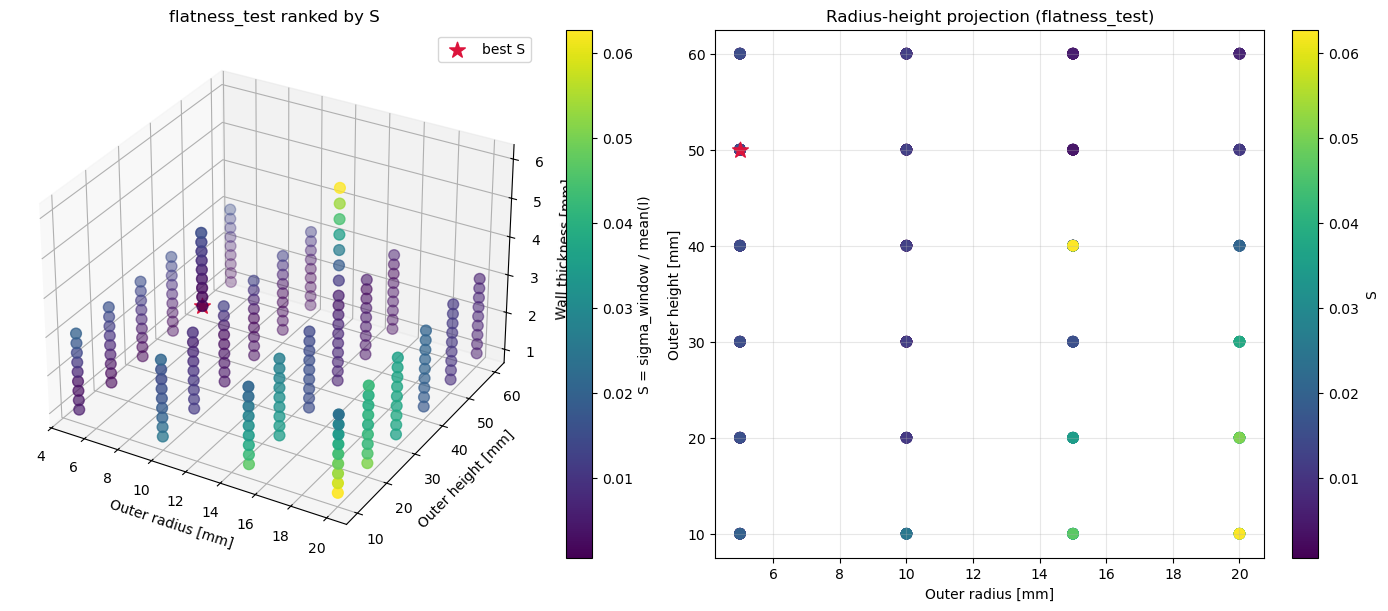

In [137]:
# Flatness test S on flatness_test data, using geometry values from mccode.sim.
# Folder layout: flatness_test/<geometry_folder>/<run_idx>/
# Each run folder must contain mccode.sim and cylinder_scattered.dat.
import re

flatness_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/flatness_test')
nominal_detector_center_deg = 75.0
center_offsets_deg = np.arange(-10.0, 10.1, 1.0)
detector_window_width_deg = 60.0
low_outlier_fraction = 0.8
equator_band_halfwidth_local = 50.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0


def parse_mccode_sim(sim_file):
    params = {}
    pattern = re.compile(r'^\s*Param:\s*([A-Za-z0-9_]+)=(.+?)\s*$')

    with sim_file.open('r') as f:
        for line in f:
            match = pattern.match(line)
            if not match:
                continue
            key = match.group(1).strip()
            raw_value = match.group(2).strip()
            try:
                params[key] = float(raw_value)
            except ValueError:
                pass

    required = ['cylinder_radius', 'cylinder_height', 'thickness']
    missing = [k for k in required if k not in params]
    if missing:
        raise ValueError(f'Missing {missing} in {sim_file}')

    # Stored in meters in mccode.sim; convert to mm.
    return {
        'outer_radius_mm': params['cylinder_radius'] * 1000.0,
        'outer_height_mm': params['cylinder_height'] * 1000.0,
        'wall_thickness_mm': params['thickness'] * 1000.0,
    }


def load_scattered_monitor(run_dir):
    loaded = ms.load_data(str(run_dir))
    if not loaded:
        raise ValueError(f'No McStas data loaded from {run_dir}')

    # Prefer the 4pi scattered monitor by filename/component name when available.
    for item in loaded:
        name = str(getattr(item, 'name', '') or '')
        component = str(getattr(item, 'component_name', '') or '')
        if 'cylinder_scattered' in name or 'mon_4pi' in component:
            return item

    # Fallback to the third item or last available item.
    return loaded[2] if len(loaded) >= 3 else loaded[-1]


def get_equator_cut_from_run(run_dir):
    sphere_mon = load_scattered_monitor(run_dir)
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local) &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )
    Hmc_corrected = np.where(~beam_center_mask, Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(~beam_center_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth_local
    equator_band = Hmc_corrected[equator_band_mask, :]
    equator_band_err = Hmc_err_corrected[equator_band_mask, :]

    nonzero_band = equator_band > 0
    equator_band = np.where(nonzero_band, equator_band, np.nan)
    equator_band_err = np.where(nonzero_band, equator_band_err, np.nan)

    equator_cut = np.nanmean(equator_band, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
        np.nan,
    )

    valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
    low_outlier_threshold = low_outlier_fraction * np.nanmedian(equator_cut[valid_cols])
    valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)

    return lon, equator_cut, equator_cut_err, valid_cols


def s_score(lon, y, valid_cols, center_deg):
    half_width = detector_window_width_deg / 2.0
    pos_min = center_deg - half_width
    pos_max = center_deg + half_width
    neg_min = -pos_max
    neg_max = -pos_min

    fit_mask = valid_cols & (((lon >= pos_min) & (lon <= pos_max)) | ((lon >= neg_min) & (lon <= neg_max)))
    y_fit = np.asarray(y)[fit_mask]
    y_fit = y_fit[np.isfinite(y_fit) & (y_fit > 0)]

    if y_fit.size < 2:
        return None

    mean_window = np.mean(y_fit)
    sigma_window = np.std(y_fit, ddof=1)
    s_value = sigma_window / mean_window if mean_window > 0 else np.nan

    return {
        'center_deg': center_deg,
        'pos_min': pos_min,
        'pos_max': pos_max,
        'neg_min': neg_min,
        'neg_max': neg_max,
        'mean_window': mean_window,
        'sigma_window': sigma_window,
        'S': s_value,
        'n_points': len(y_fit),
    }


sim_files = sorted(flatness_root.glob('**/mccode.sim'))
records = []

for sim_file in sim_files:
    run_dir = sim_file.parent
    scatter_file = run_dir / 'cylinder_scattered.dat'
    if not scatter_file.exists():
        continue

    try:
        geom = parse_mccode_sim(sim_file)
        lon, equator_cut, equator_cut_err, valid_cols = get_equator_cut_from_run(run_dir)
    except Exception:
        continue

    best_local = None
    for offset_deg in center_offsets_deg:
        center_deg = nominal_detector_center_deg + offset_deg
        score = s_score(lon, equator_cut, valid_cols, center_deg)
        if score is None:
            continue

        score.update({
            'offset_deg': offset_deg,
            'run_dir': str(run_dir),
            'geometry_dir': str(run_dir.parent),
            'lon_plot': lon[valid_cols],
            'equator_cut_plot': equator_cut[valid_cols],
            'equator_cut_err_plot': equator_cut_err[valid_cols],
            **geom,
        })

        if best_local is None or score['S'] < best_local['S']:
            best_local = score

    if best_local is not None:
        records.append(best_local)

# Sort by mccode.sim geometry values first, then by score.
records_sorted_by_geom = sorted(
    records,
    key=lambda r: (r['outer_radius_mm'], r['outer_height_mm'], r['wall_thickness_mm'], r['S'])
)
records_by_score = sorted(records, key=lambda r: r['S'])

print(f'Parsed runs: {len(records_by_score)}')
if records_by_score:
    best = records_by_score[0]
    print(
        f"Best by S: r={best['outer_radius_mm']:.2f} mm, h={best['outer_height_mm']:.2f} mm, "
        f"t={best['wall_thickness_mm']:.2f} mm, offset={best['offset_deg']:+.1f} deg, "
        f"S={best['S']:.5f}, sigma_window={best['sigma_window']:.3e}, mean_window={best['mean_window']:.3e}"
    )

    print('\nTop 12 by S:')
    for i, r in enumerate(records_by_score[:12], start=1):
        print(
            f"{i}. r={r['outer_radius_mm']:.2f} mm, h={r['outer_height_mm']:.2f} mm, "
            f"t={r['wall_thickness_mm']:.2f} mm, offset={r['offset_deg']:+.1f} deg, S={r['S']:.5f}, "
            f"sigma_window={r['sigma_window']:.3e}, mean_window={r['mean_window']:.3e}"
        )

    fig = plt.figure(figsize=(14, 6), constrained_layout=True)
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')
    sc = ax3d.scatter(
        [r['outer_radius_mm'] for r in records_by_score],
        [r['outer_height_mm'] for r in records_by_score],
        [r['wall_thickness_mm'] for r in records_by_score],
        c=[r['S'] for r in records_by_score],
        cmap='viridis',
        s=60,
    )
    ax3d.scatter(
        best['outer_radius_mm'],
        best['outer_height_mm'],
        best['wall_thickness_mm'],
        color='crimson',
        marker='*',
        s=140,
        label='best S',
    )
    ax3d.set_xlabel('Outer radius [mm]')
    ax3d.set_ylabel('Outer height [mm]')
    ax3d.set_zlabel('Wall thickness [mm]')
    ax3d.set_title('flatness_test ranked by S')
    ax3d.legend()
    fig.colorbar(sc, ax=ax3d, label='S = sigma_window / mean(I)')

    ax2d = fig.add_subplot(1, 2, 2)
    proj = ax2d.scatter(
        [r['outer_radius_mm'] for r in records_by_score],
        [r['outer_height_mm'] for r in records_by_score],
        c=[r['S'] for r in records_by_score],
        cmap='viridis',
        s=70,
        edgecolor='none',
    )
    ax2d.scatter(
        best['outer_radius_mm'],
        best['outer_height_mm'],
        color='crimson',
        marker='*',
        s=140,
    )
    ax2d.set_xlabel('Outer radius [mm]')
    ax2d.set_ylabel('Outer height [mm]')
    ax2d.set_title('Radius-height projection (flatness_test)')
    ax2d.grid(True, alpha=0.3)
    fig.colorbar(proj, ax=ax2d, label='S')

    plt.show()
else:
    print('No valid runs found in flatness_test with both mccode.sim and cylinder_scattered.dat.')
